# Supplementary Figures And Statistical Analyses

This notebook contains SI-only plots and statistical summaries supporting the main text. It intentionally reads precomputed CSV files generated by the Make targets rather than running expensive analyses inside Jupyter.

Relevant upstream commands:

```bash
make FCD_JOBS=32 paper-fcd-mw-calibration
make FCD_JOBS=32 paper-fcd-distances
```

In [1]:
from __future__ import annotations

from pathlib import Path
import importlib
import sys

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from matplotlib.ticker import MaxNLocator, PercentFormatter
from rdkit import Chem
from rdkit.Chem import Descriptors

ROOT = Path.cwd()
while not (ROOT / "results").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "notebooks"))

import paper_plot_data_loaders as plot_loaders
importlib.reload(plot_loaders)
from paper_plot_data_loaders import (
    PAPER_SEEDS_10,
    load_fcd_mw_calibration,
    load_guacamol_qed,
    load_guacamol_liability,
    load_reinvent_liability,
)

RESULTS = ROOT / "results"
FIG_DIR = ROOT / "notebooks" / "figures" / "si"
DATA_DIR = FIG_DIR / "plotting_data"
FIG_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)
PAPER_SEED_SET = set(PAPER_SEEDS_10)

mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.family": "DejaVu Sans",
    "font.size": 9.5,
    "axes.labelsize": 9.5,
    "axes.titlesize": 10.5,
    "legend.fontsize": 8.5,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.edgecolor": "#111111",
    "axes.linewidth": 0.9,
    "xtick.color": "#111111",
    "ytick.color": "#111111",
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
})

METHOD_COLORS = {
    "base": "#4B5563",
    "no_update": "#4B5563",
    "random_ne": "#A3A3A3",
    "positive": "#EE9B00",
    "topk_finetune": "#CA6702",
    "reinvent_rl": "#BB3E03",
    "ne": "#1A759F",
    "combined": "#005F73",
}
NE_LAMBDA_COLORS = {0.10: "#184E77", 0.25: "#1E6091", 0.50: "#1A759F", 0.75: "#168AAD", 1.00: "#34A0A4"}
MW_BAND_COLORS = {
    "mw_bottom_10pct": "#184E77",
    "mw_bottom_20pct": "#1E6091",
    "mw_20_40pct": "#168AAD",
    "mw_40_60pct": "#52B69A",
    "mw_60_80pct": "#B5E48C",
    "mw_top_20pct": "#EE9B00",
    "mw_top_10pct": "#CA6702",
}
MW_BAND_ORDER = [
    "base_resample",
    "mw_bottom_10pct",
    "mw_bottom_20pct",
    "mw_20_40pct",
    "mw_40_60pct",
    "mw_60_80pct",
    "mw_top_20pct",
    "mw_top_10pct",
]
MW_BAND_LABELS = {
    "base_resample": "Baseline\nresample",
    "mw_bottom_10pct": "Bottom\n10% MW",
    "mw_bottom_20pct": "Bottom\n20% MW",
    "mw_20_40pct": "20-40%\nMW",
    "mw_40_60pct": "40-60%\nMW",
    "mw_60_80pct": "60-80%\nMW",
    "mw_top_20pct": "Top\n20% MW",
    "mw_top_10pct": "Top\n10% MW",
}

def style_ax(ax):
    ax.grid(False)
    ax.tick_params(axis="both", which="major", bottom=True, left=True, length=3.5, width=0.8, color="#111111", labelcolor="#111111")
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("#111111")
        spine.set_linewidth(0.9)

def save_figure(fig, name: str):
    for suffix in ("png", "svg", "pdf"):
        fig.savefig(FIG_DIR / f"{name}.{suffix}", bbox_inches="tight")
    print(FIG_DIR / f"{name}.png")

def label_subplots(fig, labels=None, x=-0.12, y=1.045):
    axes = [ax for ax in fig.axes if ax.get_visible()]
    if labels is None:
        labels = [chr(ord("a") + i) for i in range(len(axes))]
    for ax, label in zip(axes, labels):
        ax.text(x, y, label, transform=ax.transAxes, ha="left", va="bottom", fontweight="bold", fontsize=11, color="#111111", clip_on=False)

def read_sample_smiles(path: Path) -> list[str]:
    frame = pd.read_csv(path)
    if "valid" in frame.columns:
        frame = frame[frame["valid"]]
    column = "canonical_smiles" if "canonical_smiles" in frame.columns else "smiles"
    return frame[column].dropna().astype(str).tolist()

def molecular_weight(smiles: str) -> float | None:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return float(Descriptors.MolWt(mol))

def load_baseline_mw(results_dir: Path) -> pd.DataFrame:
    rows = []
    for seed_dir in sorted(results_dir.glob("seed_*")):
        sample_path = seed_dir / "base_samples.csv"
        if not sample_path.exists():
            continue
        seed = int(seed_dir.name.removeprefix("seed_"))
        if seed not in PAPER_SEED_SET:
            continue
        for smi in read_sample_smiles(sample_path):
            mw = molecular_weight(smi)
            if mw is not None:
                rows.append({"seed": seed, "smiles": smi, "mw": mw})
    return pd.DataFrame(rows)

def mean_ci(df: pd.DataFrame, group_cols: list[str], value_col: str) -> pd.DataFrame:
    out = df.groupby(group_cols, observed=True)[value_col].agg(mean="mean", std="std", n="count").reset_index()
    out["sem"] = out["std"] / np.sqrt(out["n"].clip(lower=1))
    out["t_critical"] = out["n"].map(lambda n: float(stats.t.ppf(0.975, n - 1)) if n > 1 else np.nan)
    out["ci95"] = out["t_critical"] * out["sem"]
    return out

GuacaMol liability: (960, 133) seeds [13, 17, 19, 23, 29, 31, 37, 41, 43, 47]
REINVENT liability: (480, 131) seeds [13, 17, 19, 23, 29, 31, 37, 41, 43, 47]
GuacaMol liability: (960, 133) seeds [13, 17, 19, 23, 29, 31, 37, 41, 43, 47]
REINVENT liability: (480, 131) seeds [13, 17, 19, 23, 29, 31, 37, 41, 43, 47]


## SI Figure: Liability SMARTS Substructures

This figure renders the exact SMARTS patterns used for the four liability-erasure objectives in the main text. The table exported by this cell is a traceable copy of the pattern names and SMARTS strings imported from `neon_molgen.scoring.LIABILITY_SMARTS`.

,family,family_label,pattern,pattern_label,smarts,example_smiles,example_matches_smarts
0,reactive,Reactive motifs,acid_chloride,Acid Chloride,C(=O)Cl,CC(=O)Cl,True
1,reactive,Reactive motifs,sulfonyl_chloride,Sulfonyl Chloride,S(=O)(=O)Cl,CS(=O)(=O)Cl,True
2,reactive,Reactive motifs,isocyanate,Isocyanate,N=C=O,CN=C=O,True
3,reactive,Reactive motifs,isothiocyanate,Isothiocyanate,N=C=S,CN=C=S,True
4,reactive,Reactive motifs,aldehyde,Aldehyde,[CX3H1](=O)[#6],CC=O,True
5,reactive,Reactive motifs,epoxide,Epoxide,[OX2r3]1[#6r3][#6r3]1,CC1CO1,True
6,reactive,Reactive motifs,aziridine,Aziridine,[NX3r3]1[#6r3][#6r3]1,C1CN1,True
7,reactive,Reactive motifs,michael_acceptor,Michael Acceptor,"[C,c]=[C,c][C,S](=O)",C=CC(=O)C,True
8,reactive,Reactive motifs,alpha_beta_unsaturated_carbonyl,"alpha,beta Unsaturated Carbonyl","[C,c]=[C,c]C(=O)[#6,#7,#8]",C=CC(=O)O,True
9,reactive,Reactive motifs,alpha_beta_unsaturated_nitrile,"alpha,beta Unsaturated Nitrile","[C,c]=[C,c]C#N",C=CC#N,True


/mnt/nas/PhD/Code/neon_molecular_generation/notebooks/figures/si/si_liability_substructures.png


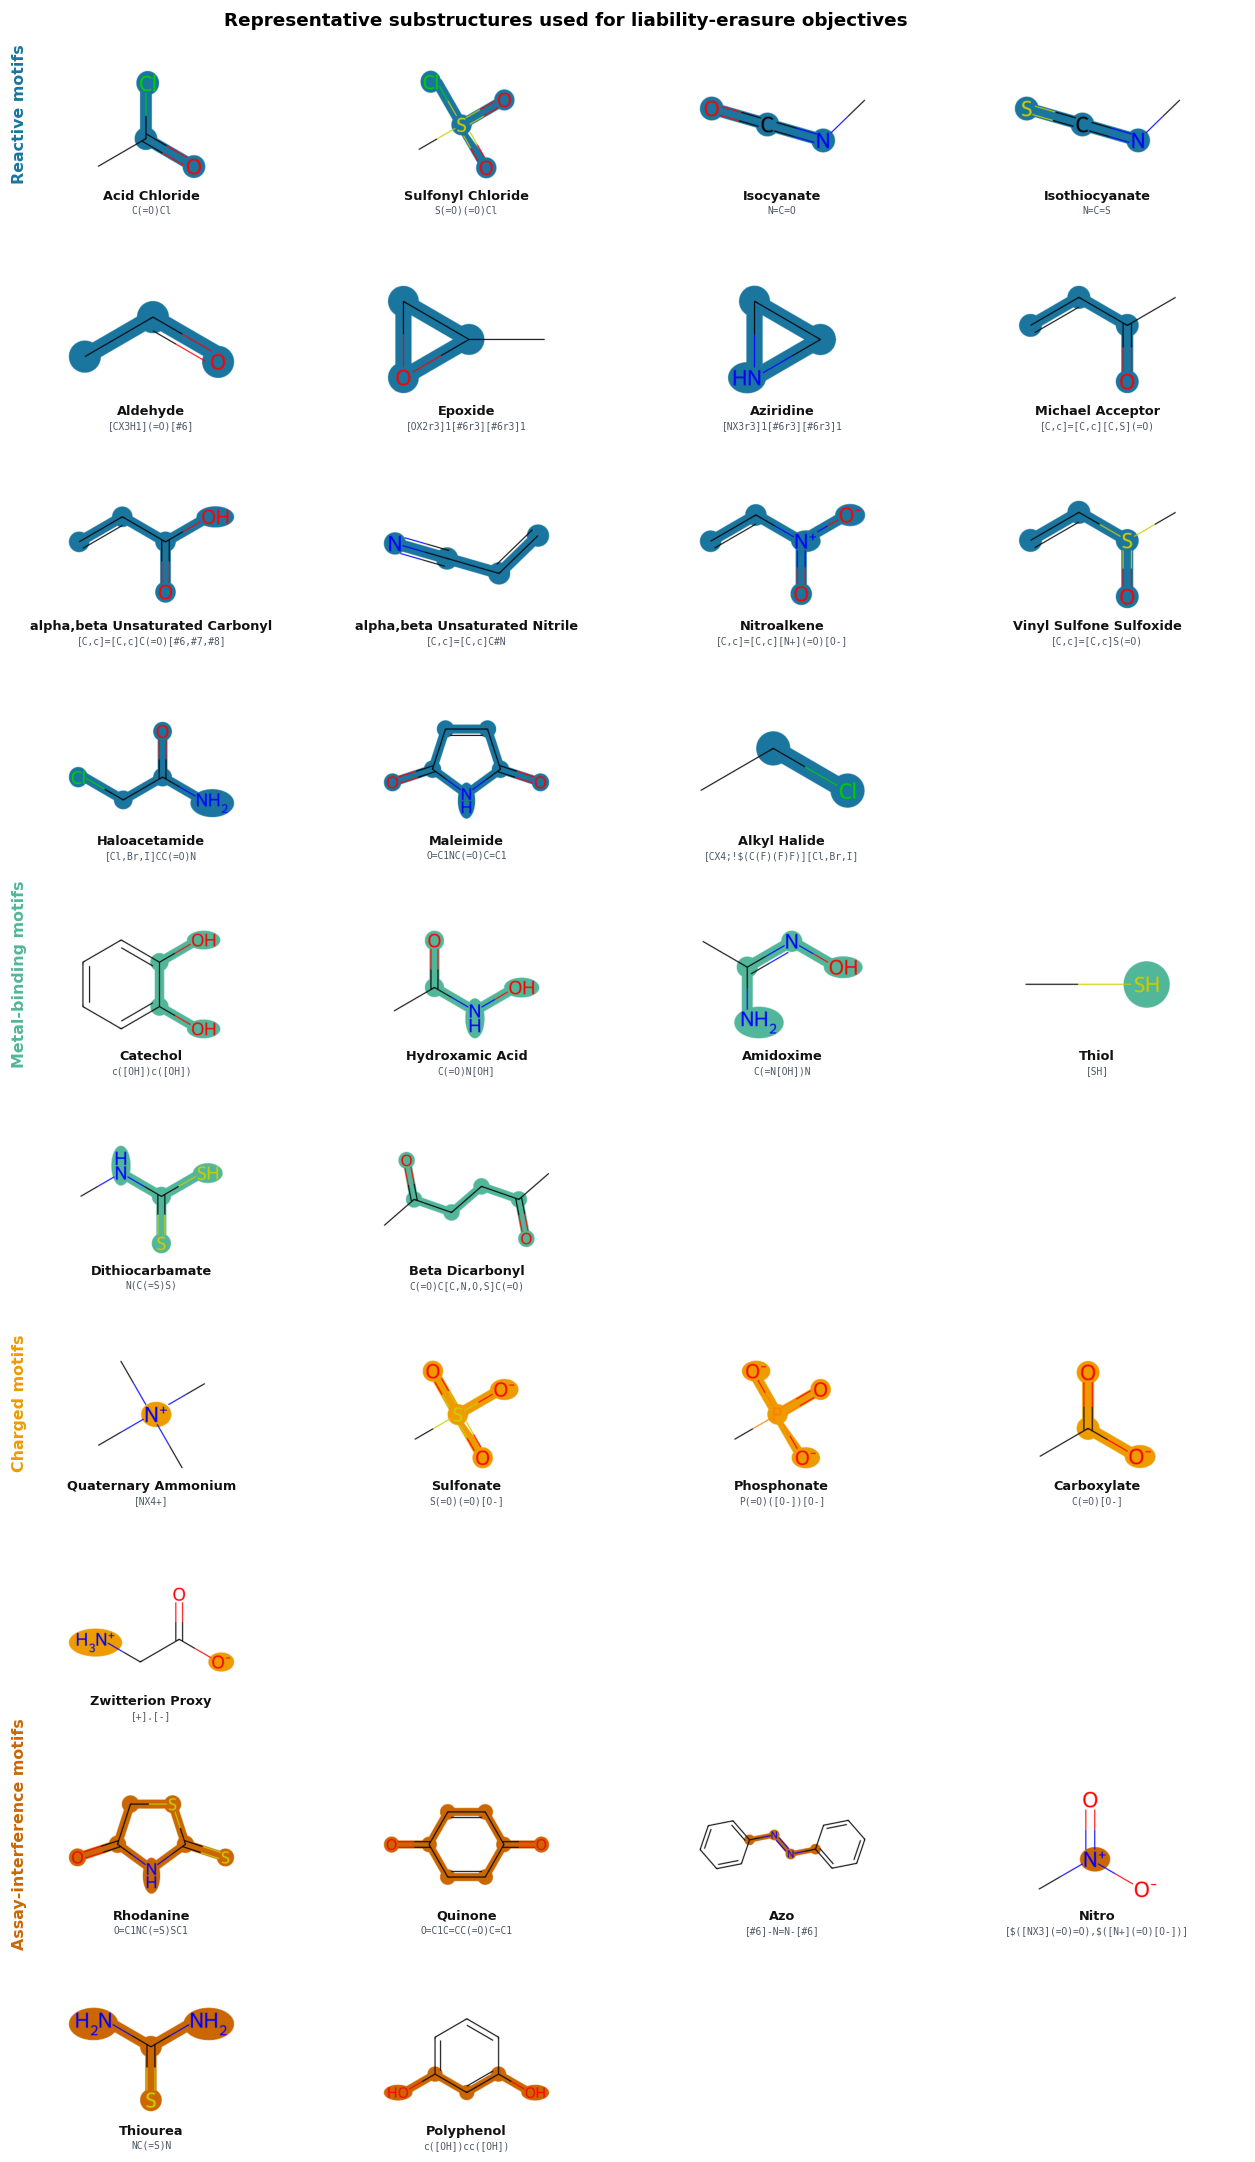

In [2]:
try:
    from rdkit.Chem import Draw, rdDepictor
except ImportError as exc:
    raise RuntimeError(
        'RDKit Draw could not be imported. Run this SI figure cell in the Jupyter/RDKit '
        'environment, or install the RDKit drawing backend dependencies such as libXrender.'
    ) from exc
from neon_molgen.scoring import LIABILITY_SMARTS
from matplotlib.colors import to_rgb

MAIN_LIABILITY_FAMILIES = {
    'reactive': 'Reactive motifs',
    'chelator': 'Metal-binding motifs',
    'charged_motif': 'Charged motifs',
    'assay_interference': 'Assay-interference motifs',
}

# Representative molecules are used for drawing because rendering SMARTS query
# molecules directly produces query-bond artifacts. The actual SMARTS pattern
# imported from neon_molgen.scoring is still used for matching/highlighting.
REPRESENTATIVE_SMILES = {
    'reactive': {
        'acid_chloride': 'CC(=O)Cl',
        'sulfonyl_chloride': 'CS(=O)(=O)Cl',
        'isocyanate': 'CN=C=O',
        'isothiocyanate': 'CN=C=S',
        'aldehyde': 'CC=O',
        'epoxide': 'CC1CO1',
        'aziridine': 'C1CN1',
        'michael_acceptor': 'C=CC(=O)C',
        'alpha_beta_unsaturated_carbonyl': 'C=CC(=O)O',
        'alpha_beta_unsaturated_nitrile': 'C=CC#N',
        'nitroalkene': 'C=C[N+](=O)[O-]',
        'vinyl_sulfone_sulfoxide': 'C=CS(=O)C',
        'haloacetamide': 'ClCC(=O)N',
        'maleimide': 'O=C1NC(=O)C=C1',
        'alkyl_halide': 'CCCl',
    },
    'chelator': {
        'catechol': 'Oc1ccccc1O',
        'hydroxamic_acid': 'CC(=O)NO',
        'amidoxime': 'CC(=N(O))N',
        'thiol': 'CS',
        'dithiocarbamate': 'N(C(=S)S)C',
        'beta_dicarbonyl': 'CC(=O)CCC(=O)C',
    },
    'charged_motif': {
        'quaternary_ammonium': 'C[N+](C)(C)C',
        'sulfonate': 'CS(=O)(=O)[O-]',
        'phosphonate': 'CP(=O)([O-])[O-]',
        'carboxylate': 'CC(=O)[O-]',
        'zwitterion_proxy': '[NH3+]CC(=O)[O-]',
    },
    'assay_interference': {
        'rhodanine': 'O=C1NC(=S)SC1',
        'quinone': 'O=C1C=CC(=O)C=C1',
        'azo': 'c1ccc(N=Nc2ccccc2)cc1',
        'nitro': 'C[N+](=O)[O-]',
        'thiourea': 'NC(=S)N',
        'polyphenol': 'Oc1cccc(O)c1',
    },
}

def pretty_pattern_name(name: str) -> str:
    label = name.replace('_', ' ').title()
    return label.replace('Alpha Beta', 'alpha,beta')

def highlight_bonds_from_match(mol, query, match):
    bonds = []
    if not match:
        return bonds
    for query_bond in query.GetBonds():
        begin = match[query_bond.GetBeginAtomIdx()]
        end = match[query_bond.GetEndAtomIdx()]
        bond = mol.GetBondBetweenAtoms(begin, end)
        if bond is not None:
            bonds.append(bond.GetIdx())
    return bonds

pattern_rows = []
for family, family_label in MAIN_LIABILITY_FAMILIES.items():
    for pattern_name, smarts in LIABILITY_SMARTS[family].items():
        example_smiles = REPRESENTATIVE_SMILES[family][pattern_name]
        mol = Chem.MolFromSmiles(example_smiles)
        query = Chem.MolFromSmarts(smarts)
        match = mol.GetSubstructMatch(query) if mol is not None and query is not None else tuple()
        pattern_rows.append({
            'family': family,
            'family_label': family_label,
            'pattern': pattern_name,
            'pattern_label': pretty_pattern_name(pattern_name),
            'smarts': smarts,
            'example_smiles': example_smiles,
            'example_matches_smarts': bool(match),
        })

liability_patterns = pd.DataFrame(pattern_rows)
liability_patterns.to_csv(DATA_DIR / 'si_liability_substructure_smarts.csv', index=False)
display(liability_patterns)
if not liability_patterns['example_matches_smarts'].all():
    print('Representative molecules without exact SMARTS match; shown without highlighted atoms:')
    display(liability_patterns[~liability_patterns['example_matches_smarts']])

family_colors = {
    'reactive': '#1A759F',
    'chelator': '#52B69A',
    'charged_motif': '#EE9B00',
    'assay_interference': '#CA6702',
}
n_cols = 4
n_rows_by_family = {
    family: int(np.ceil(len(liability_patterns[liability_patterns['family'] == family]) / n_cols))
    for family in MAIN_LIABILITY_FAMILIES
}
total_rows = sum(n_rows_by_family.values())
fig, axes = plt.subplots(total_rows, n_cols, figsize=(11.4, 1.82 * total_rows))
axes = np.asarray(axes).reshape(total_rows, n_cols)

row_offset = 0
for family, family_label in MAIN_LIABILITY_FAMILIES.items():
    family_frame = liability_patterns[liability_patterns['family'] == family].reset_index(drop=True)
    family_rows = n_rows_by_family[family]
    highlight_color = family_colors[family]
    highlight_rgb = to_rgb(highlight_color)
    for local_row in range(family_rows):
        for col in range(n_cols):
            ax = axes[row_offset + local_row, col]
            ax.set_axis_off()
            idx = local_row * n_cols + col
            if idx >= len(family_frame):
                continue
            row = family_frame.iloc[idx]
            mol = Chem.MolFromSmiles(row['example_smiles'])
            query = Chem.MolFromSmarts(row['smarts'])
            match = mol.GetSubstructMatch(query)
            try:
                rdDepictor.Compute2DCoords(mol)
            except Exception:
                pass
            highlight_atoms = list(match)
            highlight_bonds = highlight_bonds_from_match(mol, query, match)
            title_color = '#111111' if match else '#991B1B'
            image = Draw.MolToImage(
                mol,
                size=(340, 220),
                kekulize=True,
                highlightAtoms=highlight_atoms,
                highlightBonds=highlight_bonds,
                highlightColor=highlight_rgb,
            )
            ax.imshow(image)
            ax.text(0.5, -0.045, row['pattern_label'], transform=ax.transAxes, ha='center', va='top', fontsize=7.7, fontweight='bold', color=title_color)
            # Prevent recursive SMARTS '$' markers from being parsed as math delimiters.
            smarts_label = str(row['smarts']).replace('$', r'\$')
            ax.text(0.5, -0.18, smarts_label, transform=ax.transAxes, ha='center', va='top', fontsize=5.8, family='monospace', color='#4B5563', wrap=True)
    axes[row_offset, 0].text(-0.18, 0.60, family_label, transform=axes[row_offset, 0].transAxes, ha='right', va='center', rotation=90, fontweight='bold', fontsize=9.5, color=family_colors[family])
    row_offset += family_rows

fig.suptitle('Representative substructures used for liability-erasure objectives', y=0.995, fontsize=11, fontweight='bold')
fig.subplots_adjust(left=0.09, right=0.995, top=0.97, bottom=0.03, hspace=0.82, wspace=0.08)
save_figure(fig, 'si_liability_substructures')
plt.show()

## SI Figure: QED Lambda Response

Complete lambda-response curves moved from the QED main figure. Curves show ten-seed means with pointwise 95% Student-t confidence intervals; dashed lines show base and positive-fine-tuning means.

/mnt/nas/PhD/Code/neon_molecular_generation/notebooks/figures/si/si_qed_lambda_response.png


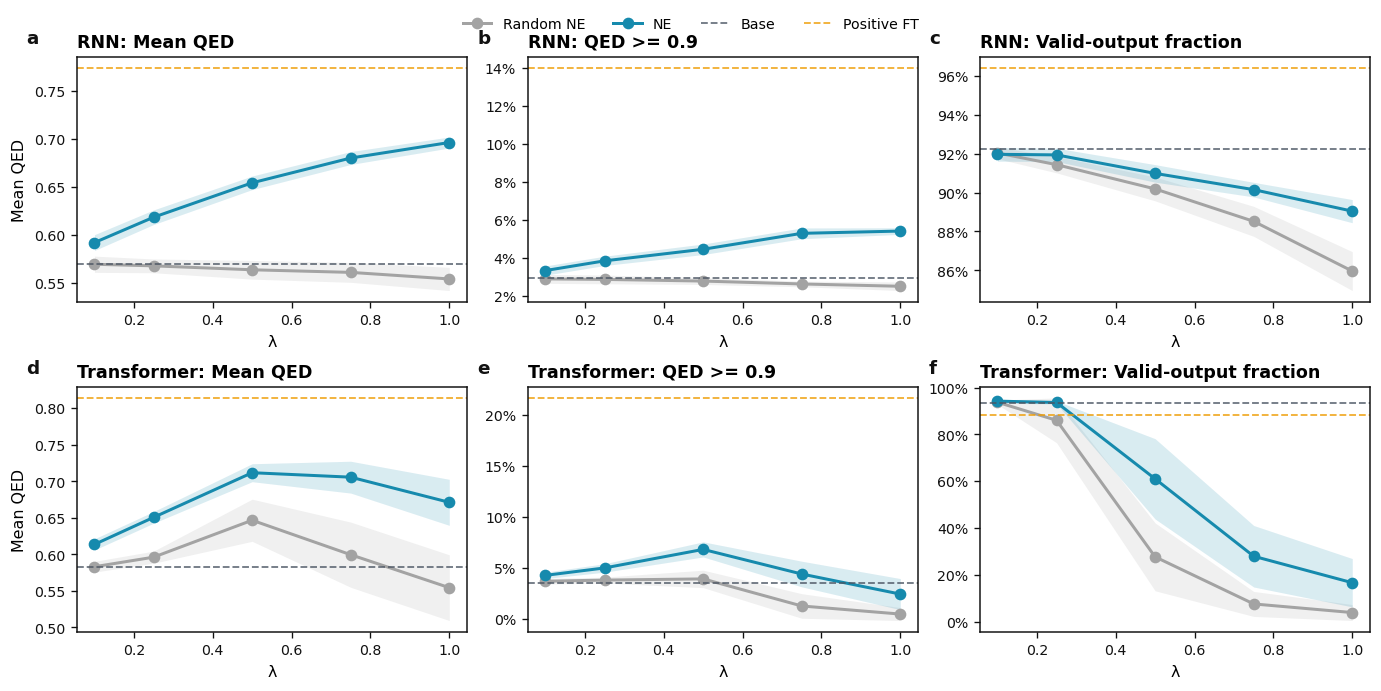

In [3]:
qed = load_guacamol_qed()
qed["model"] = qed["model"].astype(str)
QED_METRICS = [
    ("qed_mean", "Mean QED"),
    ("qed_ge_0.9_fraction", "QED >= 0.9"),
    ("valid_fraction", "Valid-output fraction"),
]

lambda_rows = []
for model in sorted(qed["model"].unique()):
    if model.startswith("neon_lambda_") or model.startswith("random_neon_lambda_"):
        try:
            lam = float(model.rsplit("_", 1)[-1])
        except ValueError:
            continue
        family = "NE" if model.startswith("neon_lambda_") else "Random NE"
        lambda_rows.append({"model": model, "lambda": lam, "family": family})
qed_lambda = qed.merge(pd.DataFrame(lambda_rows), on="model", how="inner")
qed_reference = (
    qed[qed["model"].isin(["base", "positive"])]
    .groupby(["architecture", "model"], observed=True)[[metric for metric, _ in QED_METRICS]]
    .mean()
    .reset_index()
)
lambda_summaries = {
    metric: mean_ci(qed_lambda, ["architecture", "family", "lambda"], metric)
    for metric, _ in QED_METRICS
}

fig, axes = plt.subplots(2, 3, figsize=(11.4, 5.5), constrained_layout=True)
family_colors = {"NE": NE_LAMBDA_COLORS[0.75], "Random NE": METHOD_COLORS["random_ne"]}
for row, architecture in enumerate(["RNN", "Transformer"]):
    refs = qed_reference[qed_reference["architecture"].eq(architecture)]
    for col, (metric, ylabel) in enumerate(QED_METRICS):
        ax = axes[row, col]
        part = lambda_summaries[metric]
        part = part[part["architecture"].eq(architecture)]
        for family in ["Random NE", "NE"]:
            fam = part[part["family"].eq(family)].sort_values("lambda")
            ax.plot(fam["lambda"], fam["mean"], marker="o", lw=1.8, color=family_colors[family], label=family)
            ax.fill_between(
                fam["lambda"].to_numpy(float),
                (fam["mean"] - fam["ci95"]).to_numpy(float),
                (fam["mean"] + fam["ci95"]).to_numpy(float),
                color=family_colors[family], alpha=0.16, linewidth=0,
            )
        for model, color, label in [
            ("base", METHOD_COLORS["base"], "Base"),
            ("positive", METHOD_COLORS["positive"], "Positive FT"),
        ]:
            ref = refs[refs["model"].eq(model)]
            if not ref.empty:
                ax.axhline(float(ref[metric].iloc[0]), color=color, lw=1.1, ls="--", alpha=0.8, label=label)
        ax.set_title(f"{architecture}: {ylabel}", loc="left", fontweight="bold")
        ax.set_xlabel("λ")
        ax.set_ylabel(ylabel if col == 0 else "")
        if metric.endswith("fraction"):
            ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
        style_ax(ax)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False, bbox_to_anchor=(0.5, 1.03))
label_subplots(fig, x=-0.13, y=1.04)
save_figure(fig, "si_qed_lambda_response")
plt.show()
qed_lambda.to_csv(DATA_DIR / "si_qed_lambda_response.csv", index=False)

## SI Figure: Complete Liability-Removal Endpoints

All four structural objectives are shown for the RNN, scoped Transformer, and REINVENT prior. The main text uses metal-binding motifs as the representative matched application; this figure documents the directionally consistent target suppression for reactive, charged, and assay-interference motifs as well.

/tmp/ipykernel_15504/4112605425.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_15504/4112605425.py:105: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
/tmp/ipykernel_15504/4112605425.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_15504/4112605425.py:105: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
/tmp/ipykernel_15504/4112605425.py:94: FutureWarning: 

/tmp/ipykernel_15504/4112605425.py:105: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
/tmp/ipykernel_15504/4112605425.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_15504/4112605425.py:105: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
/tmp/ipykernel_15504/4112605425.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_15504/4112605425.py:105: UserWarning: s

/tmp/ipykernel_15504/4112605425.py:105: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
/tmp/ipykernel_15504/4112605425.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_15504/4112605425.py:105: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
/tmp/ipykernel_15504/4112605425.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_15504/4112605425.py:105: UserWarning: s

/tmp/ipykernel_15504/4112605425.py:105: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
/tmp/ipykernel_15504/4112605425.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_15504/4112605425.py:105: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
/tmp/ipykernel_15504/4112605425.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_15504/4112605425.py:105: UserWarning: s

/mnt/nas/PhD/Code/neon_molecular_generation/notebooks/figures/si/si_all_liability_endpoints.png


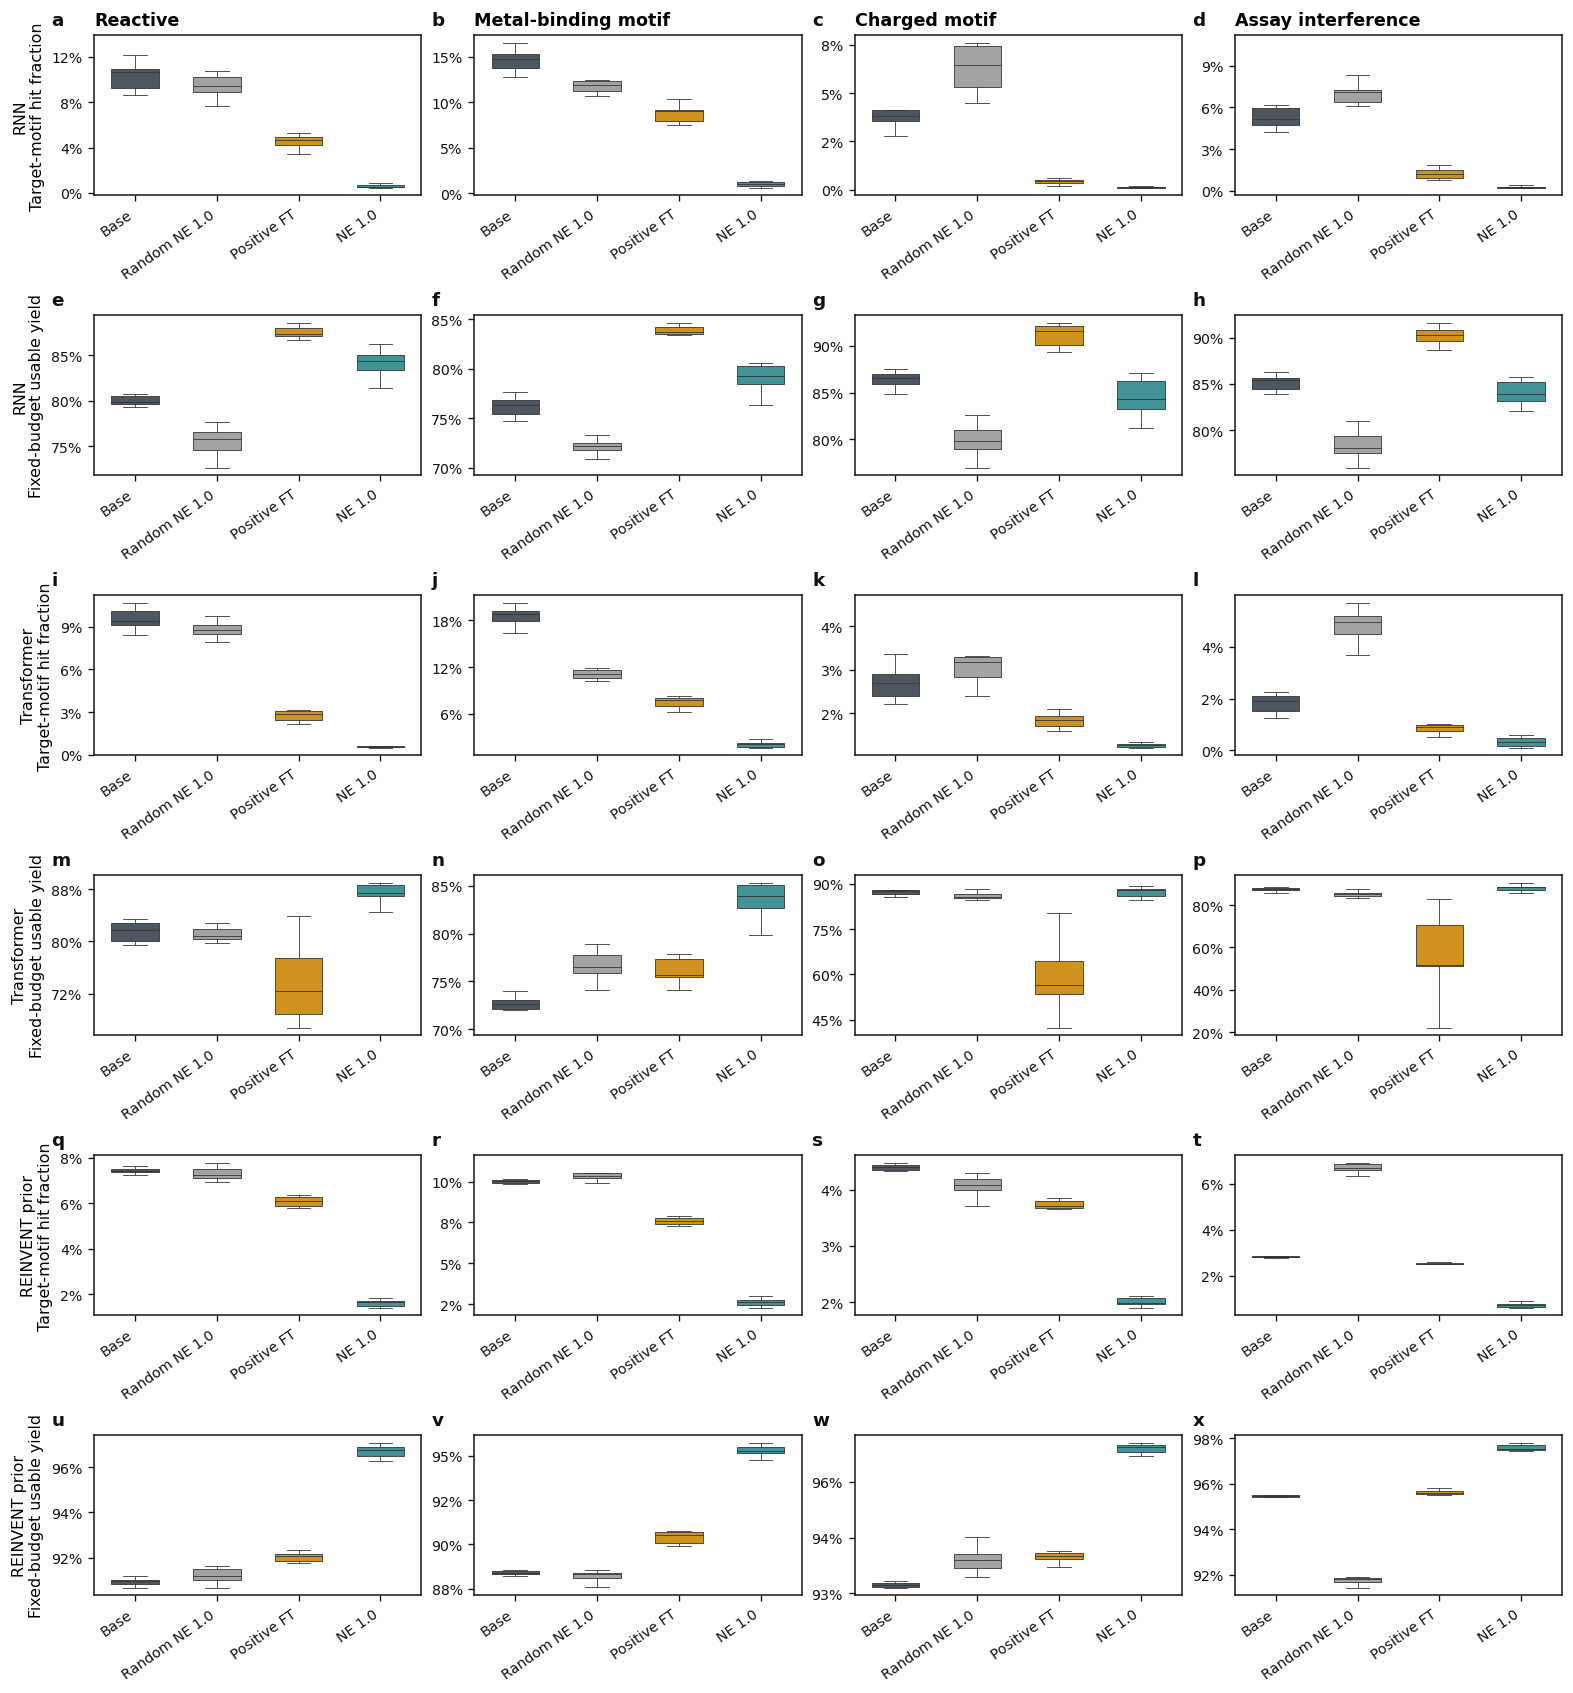

In [4]:
SI_OBJECTIVE_ORDER = ["Reactive", "Metal-binding motif", "Charged motif", "Assay interference"]
SI_METHOD_ORDER = ["base", "random_ne", "positive", "ne"]
SI_METHOD_LABELS = {
    "base": "Base",
    "random_ne": "Random NE 1.0",
    "positive": "Positive FT",
    "ne": "NE 1.0",
}
SI_METHOD_COLORS = {
    "base": METHOD_COLORS["base"],
    "random_ne": METHOD_COLORS["random_ne"],
    "positive": METHOD_COLORS["positive"],
    "ne": NE_LAMBDA_COLORS[1.00],
}


def si_guacamol_method(model: str) -> str | None:
    model = str(model)
    if model == "base":
        return "base"
    if model == "positive":
        return "positive"
    if model in {
        "neon_lambda_1", "neon_lambda_1.0",
        "neon_last_block_output_lambda_1", "neon_last_block_output_lambda_1.0",
    }:
        return "ne"
    if model in {
        "random_neon_lambda_1", "random_neon_lambda_1.0",
        "random_neon_last_block_output_lambda_1", "random_neon_last_block_output_lambda_1.0",
    }:
        return "random_ne"
    return None


def si_reinvent_method(model: str) -> str | None:
    return {
        "base": "base",
        "random_neon_lambda_1": "random_ne",
        "positive": "positive",
        "neon_lambda_1": "ne",
    }.get(str(model))


def si_parse_lambda(model: str):
    model = str(model)
    prefixes = [
        ("random_neon_last_block_output_lambda_", "Random NE"),
        ("random_neon_lambda_", "Random NE"),
        ("neon_last_block_output_lambda_", "NE"),
        ("neon_lambda_", "NE"),
    ]
    for prefix, family in prefixes:
        if model.startswith(prefix):
            try:
                return {"family": family, "lambda": float(model.removeprefix(prefix))}
            except ValueError:
                return None
    return None


guacamol_all = load_guacamol_liability()
reinvent_all = load_reinvent_liability()
guacamol_all["method"] = guacamol_all["model"].map(si_guacamol_method)
reinvent_all["method"] = reinvent_all["model"].map(si_reinvent_method)
guacamol_all = guacamol_all[guacamol_all["method"].isin(SI_METHOD_ORDER)].copy()
reinvent_all = reinvent_all[reinvent_all["method"].isin(SI_METHOD_ORDER)].copy()
guacamol_all["generator"] = guacamol_all["architecture"]
reinvent_all["generator"] = "REINVENT prior"
all_endpoints = pd.concat([guacamol_all, reinvent_all], ignore_index=True, sort=False)
all_endpoints["method_label"] = all_endpoints["method"].map(SI_METHOD_LABELS)
all_endpoints["method_label"] = pd.Categorical(
    all_endpoints["method_label"],
    [SI_METHOD_LABELS[m] for m in SI_METHOD_ORDER],
    ordered=True,
)

fig, axes = plt.subplots(6, 4, figsize=(13.0, 14.0), constrained_layout=True)
row_specs = [
    ("RNN", "target_hit_fraction", "RNN\nTarget-motif hit fraction"),
    ("RNN", "usable_yield", "RNN\nFixed-budget usable yield"),
    ("Transformer", "target_hit_fraction", "Transformer\nTarget-motif hit fraction"),
    ("Transformer", "usable_yield", "Transformer\nFixed-budget usable yield"),
    ("REINVENT prior", "target_hit_fraction", "REINVENT prior\nTarget-motif hit fraction"),
    ("REINVENT prior", "usable_yield", "REINVENT prior\nFixed-budget usable yield"),
]
for row, (generator, metric, ylabel) in enumerate(row_specs):
    for col, objective in enumerate(SI_OBJECTIVE_ORDER):
        ax = axes[row, col]
        panel = all_endpoints[
            all_endpoints["generator"].eq(generator)
            & all_endpoints["objective_label"].eq(objective)
        ]
        sns.boxplot(
            data=panel, x="method_label", y=metric,
            order=[SI_METHOD_LABELS[m] for m in SI_METHOD_ORDER],
            palette=[SI_METHOD_COLORS[m] for m in SI_METHOD_ORDER],
            width=0.58, linewidth=0.5, fliersize=0, ax=ax,
        )
        ax.set_title(objective if row == 0 else "", loc="left", fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel(ylabel if col == 0 else "")
        ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
        ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
        ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
        style_ax(ax)

label_subplots(fig, x=-0.13, y=1.04)
save_figure(fig, "si_all_liability_endpoints")
plt.show()
all_endpoints.to_csv(DATA_DIR / "si_all_liability_endpoints.csv", index=False)

## SI Figure: Liability Lambda Responses Across String-Based Generators

Complete target-removal and valid-output responses for the RNN, scoped Transformer, and pretrained REINVENT prior across all four structural objectives. Each generator retains the lambda grid used in its experiment; curves show ten-seed means with pointwise 95% Student-t confidence intervals, and dashed lines show base and positive-fine-tuning means.

/mnt/nas/PhD/Code/neon_molecular_generation/notebooks/figures/si/si_all_liability_lambda_responses.png


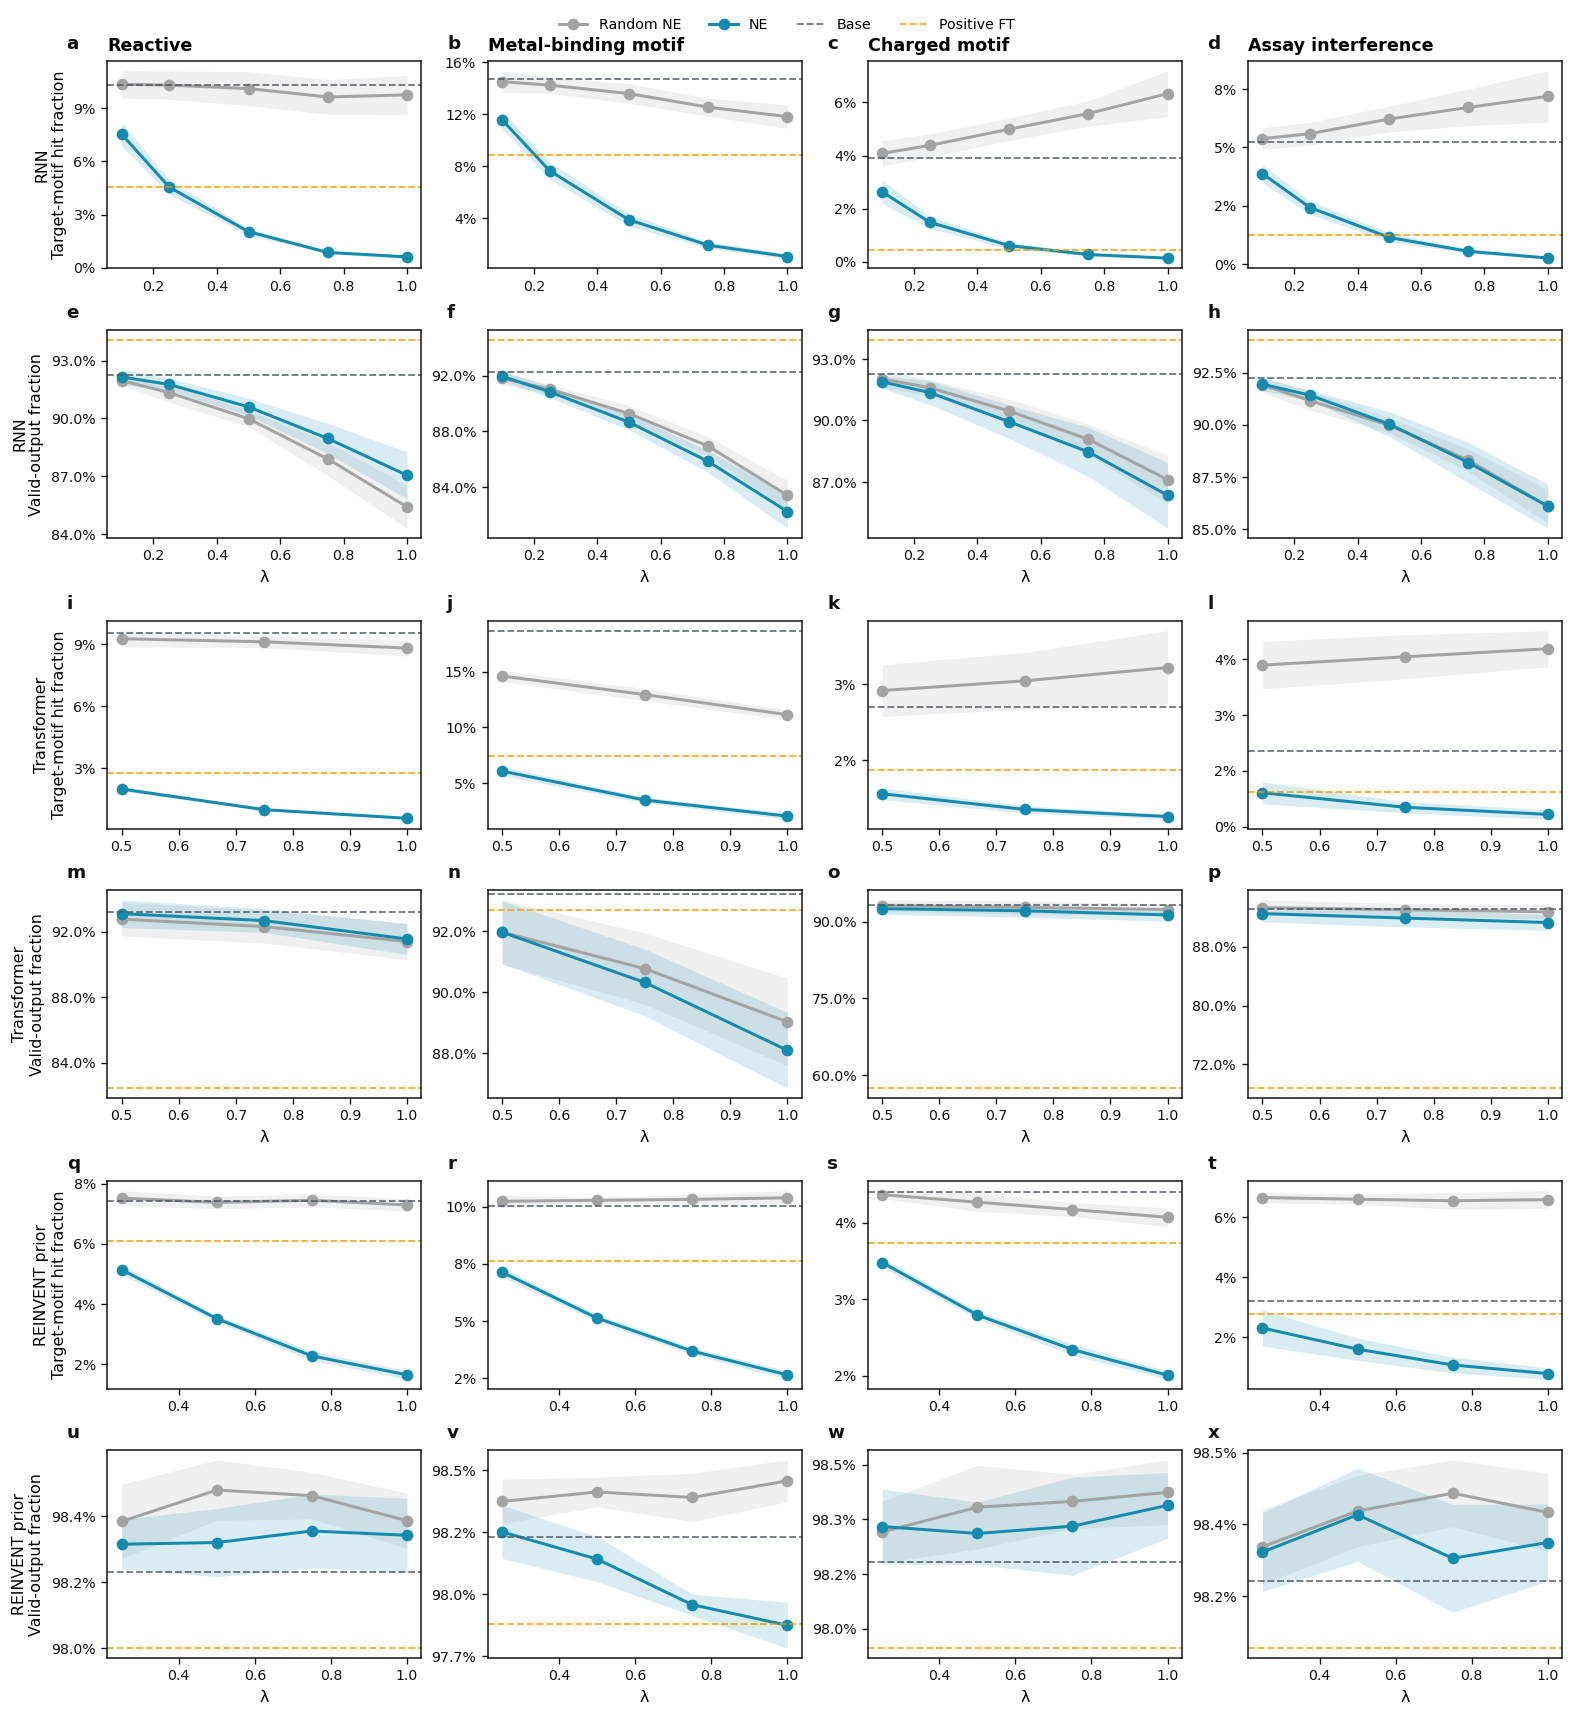

In [5]:
SI_OBJECTIVE_ORDER = ["Reactive", "Metal-binding motif", "Charged motif", "Assay interference"]


def si_parse_lambda(model: str):
    model = str(model)
    prefixes = [
        ("random_neon_last_block_output_lambda_", "Random NE"),
        ("random_neon_lambda_", "Random NE"),
        ("neon_last_block_output_lambda_", "NE"),
        ("neon_lambda_", "NE"),
    ]
    for prefix, family in prefixes:
        if model.startswith(prefix):
            try:
                return {"family": family, "lambda": float(model.removeprefix(prefix))}
            except ValueError:
                return None
    return None


guacamol_lambda_raw = load_guacamol_liability()
guacamol_parsed = guacamol_lambda_raw["model"].map(si_parse_lambda).apply(
    lambda value: pd.Series(value) if value else pd.Series(dtype=float)
)
guacamol_lambda = pd.concat([guacamol_lambda_raw, guacamol_parsed], axis=1)
guacamol_lambda = guacamol_lambda[
    guacamol_lambda["family"].isin(["Random NE", "NE"])
].copy()
guacamol_lambda["objective_label"] = pd.Categorical(
    guacamol_lambda["objective_label"], SI_OBJECTIVE_ORDER, ordered=True
)
guacamol_reference = (
    guacamol_lambda_raw[guacamol_lambda_raw["model"].isin(["base", "positive"])]
    .groupby(["architecture", "objective_label", "model"], observed=True)[
        ["target_hit_fraction", "valid_fraction"]
    ]
    .mean()
    .reset_index()
)

reinvent_lambda_raw = load_reinvent_liability()
reinvent_parsed = reinvent_lambda_raw["model"].map(si_parse_lambda).apply(
    lambda value: pd.Series(value) if value else pd.Series(dtype=float)
)
reinvent_lambda = pd.concat([reinvent_lambda_raw, reinvent_parsed], axis=1)
reinvent_lambda = reinvent_lambda[
    reinvent_lambda["family"].isin(["Random NE", "NE"])
].copy()
reinvent_lambda["objective_label"] = pd.Categorical(
    reinvent_lambda["objective_label"], SI_OBJECTIVE_ORDER, ordered=True
)
reinvent_reference = (
    reinvent_lambda_raw[reinvent_lambda_raw["model"].isin(["base", "positive"])]
    .groupby(["objective_label", "model"], observed=True)[
        ["target_hit_fraction", "output_yield_fraction"]
    ]
    .mean()
    .reset_index()
)

family_colors = {
    "Random NE": METHOD_COLORS["random_ne"],
    "NE": NE_LAMBDA_COLORS[0.75],
}
row_specs = [
    ("RNN", guacamol_lambda, guacamol_reference, "target_hit_fraction", "RNN\nTarget-motif hit fraction"),
    ("RNN", guacamol_lambda, guacamol_reference, "valid_fraction", "RNN\nValid-output fraction"),
    ("Transformer", guacamol_lambda, guacamol_reference, "target_hit_fraction", "Transformer\nTarget-motif hit fraction"),
    ("Transformer", guacamol_lambda, guacamol_reference, "valid_fraction", "Transformer\nValid-output fraction"),
    ("REINVENT prior", reinvent_lambda, reinvent_reference, "target_hit_fraction", "REINVENT prior\nTarget-motif hit fraction"),
    ("REINVENT prior", reinvent_lambda, reinvent_reference, "output_yield_fraction", "REINVENT prior\nValid-output fraction"),
]

fig, axes = plt.subplots(6, 4, figsize=(13.0, 14.0), constrained_layout=True)
for row, (generator, data, reference, metric, ylabel) in enumerate(row_specs):
    if generator in {"RNN", "Transformer"}:
        data = data[data["architecture"].eq(generator)]
        reference = reference[reference["architecture"].eq(generator)]
    summary = mean_ci(data, ["objective_label", "family", "lambda"], metric)

    for col, objective in enumerate(SI_OBJECTIVE_ORDER):
        ax = axes[row, col]
        panel = summary[summary["objective_label"].astype(str).eq(objective)]
        for family in ["Random NE", "NE"]:
            part = panel[panel["family"].eq(family)].sort_values("lambda")
            ax.plot(
                part["lambda"], part["mean"], marker="o", lw=1.8,
                color=family_colors[family], label=family,
            )
            ax.fill_between(
                part["lambda"].to_numpy(float),
                (part["mean"] - part["ci95"]).to_numpy(float),
                (part["mean"] + part["ci95"]).to_numpy(float),
                color=family_colors[family], alpha=0.16, linewidth=0,
            )

        refs = reference[reference["objective_label"].eq(objective)]
        for model, color, label in [
            ("base", METHOD_COLORS["base"], "Base"),
            ("positive", METHOD_COLORS["positive"], "Positive FT"),
        ]:
            ref = refs[refs["model"].eq(model)]
            if not ref.empty:
                ax.axhline(
                    float(ref[metric].iloc[0]), color=color, lw=1.1,
                    ls="--", alpha=0.8, label=label,
                )

        ax.set_title(objective if row == 0 else "", loc="left", fontweight="bold")
        ax.set_xlabel("λ" if row in {1, 3, 5} else "")
        ax.set_ylabel(ylabel if col == 0 else "")
        ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
        decimals = 1 if metric in {"valid_fraction", "output_yield_fraction"} else 0
        ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=decimals))
        style_ax(ax)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels, loc="upper center", ncol=4,
    frameon=False, bbox_to_anchor=(0.5, 1.015),
)
label_subplots(fig, x=-0.13, y=1.04)
save_figure(fig, "si_all_liability_lambda_responses")
plt.show()

guacamol_export = guacamol_lambda.copy()
guacamol_export["generator"] = guacamol_export["architecture"]
guacamol_export["validity_metric"] = "valid_fraction"
reinvent_export = reinvent_lambda.copy()
reinvent_export["generator"] = "REINVENT prior"
reinvent_export["validity_metric"] = "output_yield_fraction"
pd.concat([guacamol_export, reinvent_export], ignore_index=True, sort=False).to_csv(
    DATA_DIR / "si_all_liability_lambda_responses.csv", index=False
)

## SI Figure: Structural Diversity For The Representative Liability

Unique Bemis-Murcko scaffold fractions and mean pairwise Morgan-fingerprint Tanimoto distances for the metal-binding-motif experiment in all three string-based generators.

/tmp/ipykernel_15504/3359594951.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_15504/3359594951.py:111: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
/tmp/ipykernel_15504/3359594951.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_15504/3359594951.py:111: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
/tmp/ipykernel_15504/3359594951.py:99: FutureWarning: 

/mnt/nas/PhD/Code/neon_molecular_generation/notebooks/figures/si/si_metal_binding_structural_diversity.png


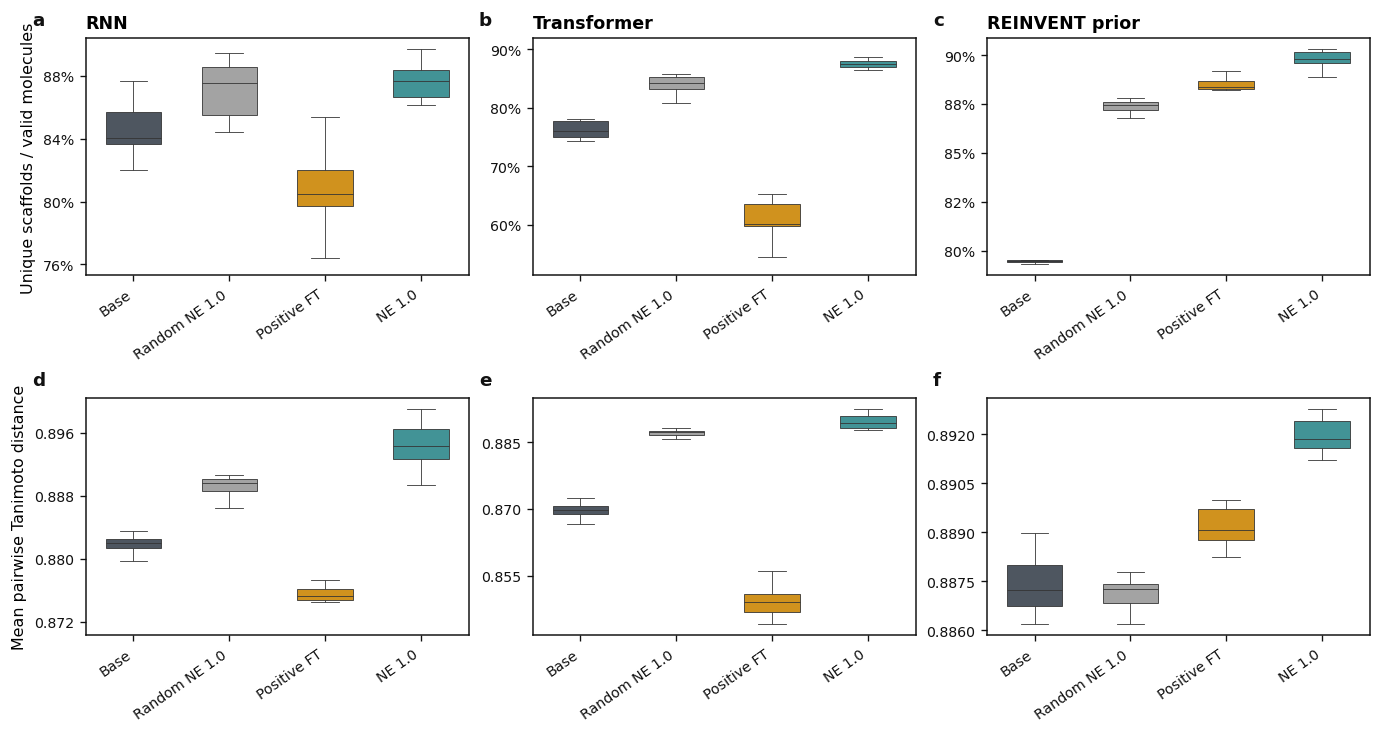

In [6]:
SI_OBJECTIVE_ORDER = ["Reactive", "Metal-binding motif", "Charged motif", "Assay interference"]
SI_METHOD_ORDER = ["base", "random_ne", "positive", "ne"]
SI_METHOD_LABELS = {
    "base": "Base",
    "random_ne": "Random NE 1.0",
    "positive": "Positive FT",
    "ne": "NE 1.0",
}
SI_METHOD_COLORS = {
    "base": METHOD_COLORS["base"],
    "random_ne": METHOD_COLORS["random_ne"],
    "positive": METHOD_COLORS["positive"],
    "ne": NE_LAMBDA_COLORS[1.00],
}


def si_guacamol_method(model: str) -> str | None:
    model = str(model)
    if model == "base":
        return "base"
    if model == "positive":
        return "positive"
    if model in {
        "neon_lambda_1", "neon_lambda_1.0",
        "neon_last_block_output_lambda_1", "neon_last_block_output_lambda_1.0",
    }:
        return "ne"
    if model in {
        "random_neon_lambda_1", "random_neon_lambda_1.0",
        "random_neon_last_block_output_lambda_1", "random_neon_last_block_output_lambda_1.0",
    }:
        return "random_ne"
    return None


def si_reinvent_method(model: str) -> str | None:
    return {
        "base": "base",
        "random_neon_lambda_1": "random_ne",
        "positive": "positive",
        "neon_lambda_1": "ne",
    }.get(str(model))


def si_parse_lambda(model: str):
    model = str(model)
    prefixes = [
        ("random_neon_last_block_output_lambda_", "Random NE"),
        ("random_neon_lambda_", "Random NE"),
        ("neon_last_block_output_lambda_", "NE"),
        ("neon_lambda_", "NE"),
    ]
    for prefix, family in prefixes:
        if model.startswith(prefix):
            try:
                return {"family": family, "lambda": float(model.removeprefix(prefix))}
            except ValueError:
                return None
    return None


DIVERSITY_SOURCES = {
    "RNN": (
        RESULTS / "objectives/guacamol_rnn_chelator_removal/analysis/diversity_selected_10seed/diversity_metrics.csv",
        si_guacamol_method,
    ),
    "Transformer": (
        RESULTS / "objectives/guacamol_transformer_chelator_lastblock_final/analysis/diversity_selected_10seed/diversity_metrics.csv",
        si_guacamol_method,
    ),
    "REINVENT prior": (
        RESULTS / "external/reinvent4/chelator_replicates/analysis/diversity/diversity_metrics.csv",
        si_reinvent_method,
    ),
}
frames = []
for generator, (path, normalizer) in DIVERSITY_SOURCES.items():
    frame = pd.read_csv(path)
    frame = frame[frame["seed"].isin(PAPER_SEEDS_10)].copy()
    frame["method"] = frame["model"].map(normalizer)
    frame = frame[frame["method"].isin(SI_METHOD_ORDER)].copy()
    frame["generator"] = generator
    frame["method_label"] = frame["method"].map(SI_METHOD_LABELS)
    frames.append(frame)
diversity_data = pd.concat(frames, ignore_index=True)
diversity_data["method_label"] = pd.Categorical(
    diversity_data["method_label"],
    [SI_METHOD_LABELS[m] for m in SI_METHOD_ORDER], ordered=True,
)

fig, axes = plt.subplots(2, 3, figsize=(11.4, 6.0), constrained_layout=True)
for col, generator in enumerate(DIVERSITY_SOURCES):
    panel = diversity_data[diversity_data["generator"].eq(generator)]
    for row, (metric, ylabel, percent) in enumerate([
        ("unique_scaffold_fraction", "Unique scaffolds / valid molecules", True),
        ("pairwise_tanimoto_distance_mean", "Mean pairwise Tanimoto distance", False),
    ]):
        ax = axes[row, col]
        sns.boxplot(
            data=panel, x="method_label", y=metric,
            order=[SI_METHOD_LABELS[m] for m in SI_METHOD_ORDER],
            palette=[SI_METHOD_COLORS[m] for m in SI_METHOD_ORDER],
            width=0.58, linewidth=0.5, fliersize=0, ax=ax,
        )
        ax.set_title(generator if row == 0 else "", loc="left", fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel(ylabel if col == 0 else "")
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
        if percent:
            ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
        ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
        style_ax(ax)

label_subplots(fig, x=-0.14, y=1.04)
save_figure(fig, "si_metal_binding_structural_diversity")
plt.show()
diversity_data.to_csv(DATA_DIR / "si_metal_binding_structural_diversity.csv", index=False)

## SI Figure: Molecular-Weight Calibration For FCD And FDD

This figure provides experiment-local rulers for the distribution-distance axes. We compare molecular-weight-filtered subsets of each baseline generator against the corresponding unfiltered baseline reference. The rows use the same calibration procedure for the RNN, Transformer, and REINVENT prior, so each FCD/FDD axis is anchored to chemically interpretable low- and high-MW shifts from the same generator family.

In [7]:
CALIBRATION_SOURCES = {
    "RNN": {
        "results_dir": RESULTS / "objectives/guacamol_rnn_chelator_removal",
        "calibration_dir": RESULTS / "objectives/guacamol_rnn_chelator_removal/analysis/fcd_mw_calibration",
    },
    "Transformer": {
        "results_dir": RESULTS / "objectives/guacamol_transformer_chelator_lastblock_final",
        "calibration_dir": RESULTS / "objectives/guacamol_transformer_chelator_lastblock_final/analysis/fcd_mw_calibration",
    },
    "REINVENT prior": {
        "results_dir": RESULTS / "external/reinvent4/chelator_replicates",
        "calibration_dir": RESULTS / "external/reinvent4/chelator_replicates/analysis/fcd_mw_calibration",
    },
}

calibration_data = {}
for generator, paths in CALIBRATION_SOURCES.items():
    baseline_mw = load_baseline_mw(paths["results_dir"])
    try:
        calibration_metrics, calibration_summary = load_fcd_mw_calibration(folder=paths["calibration_dir"])
    except FileNotFoundError as exc:
        calibration_metrics = pd.DataFrame()
        calibration_summary = pd.DataFrame()
        print(f"Missing calibration for {generator}. Run the corresponding paper-fcd-mw-calibration target.")
        print(exc)
    calibration_data[generator] = {
        "baseline_mw": baseline_mw,
        "metrics": calibration_metrics,
        "summary": calibration_summary,
    }
    print(f"{generator}: baseline MW rows={len(baseline_mw):,}, calibration rows={len(calibration_metrics):,}")

RNN: baseline MW rows=92,254, calibration rows=80


Transformer: baseline MW rows=93,210, calibration rows=80


REINVENT prior: baseline MW rows=491,157, calibration rows=80


/tmp/ipykernel_15504/3469795251.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_15504/3469795251.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_15504/3469795251.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_15504/3469795251.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_15504/3469795251.py:32: FutureWarning: 



/tmp/ipykernel_15504/3469795251.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_15504/3469795251.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_15504/3469795251.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_15504/3469795251.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_15504/3469795251.py:45: UserWarning: set_

/mnt/nas/PhD/Code/neon_molecular_generation/notebooks/figures/si/si_fcd_fdd_mw_calibration_all_generators.png


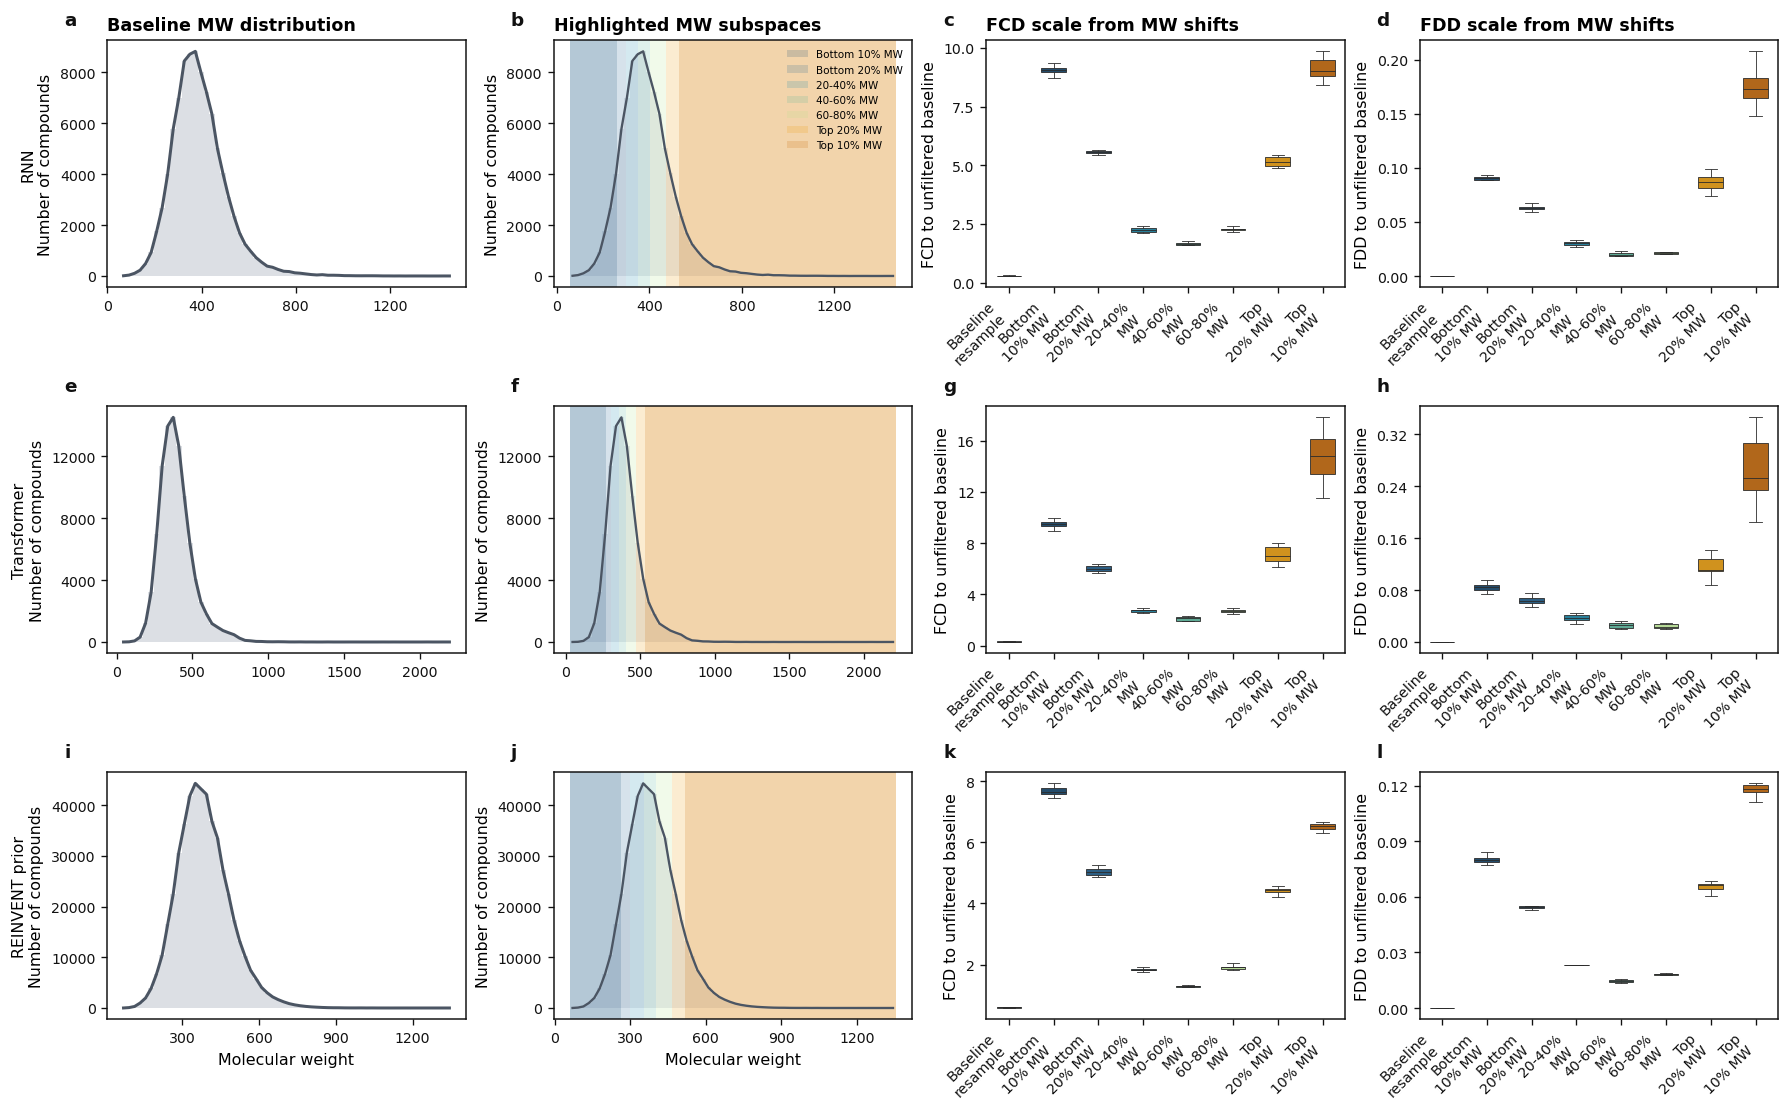

In [8]:
def mw_histogram_arrays(frame: pd.DataFrame, bins: int = 60):
    mw_values = frame["mw"].dropna().to_numpy()
    if len(mw_values) == 0:
        return np.array([]), np.array([]), np.array([]), {}
    counts, edges = np.histogram(mw_values, bins=bins)
    centers = 0.5 * (edges[:-1] + edges[1:])
    quantiles = frame["mw"].quantile([0.1, 0.2, 0.4, 0.6, 0.8, 0.9]).to_dict()
    return mw_values, counts, centers, quantiles

def mw_span_definitions(mw_values: np.ndarray, quantiles: dict[float, float]):
    return [
        ("mw_bottom_10pct", float(mw_values.min()), quantiles[0.1]),
        ("mw_bottom_20pct", float(mw_values.min()), quantiles[0.2]),
        ("mw_20_40pct", quantiles[0.2], quantiles[0.4]),
        ("mw_40_60pct", quantiles[0.4], quantiles[0.6]),
        ("mw_60_80pct", quantiles[0.6], quantiles[0.8]),
        ("mw_top_20pct", quantiles[0.8], float(mw_values.max())),
        ("mw_top_10pct", quantiles[0.9], float(mw_values.max())),
    ]

def prepare_calibration_metrics(frame: pd.DataFrame) -> pd.DataFrame:
    if frame.empty:
        return frame.copy()
    out = frame[frame["band"].isin(MW_BAND_ORDER)].copy()
    out["band"] = pd.Categorical(out["band"], MW_BAND_ORDER, ordered=True)
    out["band_label_plot"] = out["band"].astype(str).map(MW_BAND_LABELS)
    return out

def plot_calibration_box(ax, metrics: pd.DataFrame, metric: str, ylabel: str, title: str | None = None):
    if not metrics.empty and metric in metrics.columns:
        palette = ["#9CA3AF" if band == "base_resample" else MW_BAND_COLORS.get(band, "#9CA3AF") for band in MW_BAND_ORDER]
        sns.boxplot(
            data=metrics,
            x="band_label_plot",
            y=metric,
            order=[MW_BAND_LABELS[band] for band in MW_BAND_ORDER],
            palette=palette,
            width=0.55,
            linewidth=0.5,
            fliersize=0,
            ax=ax,
        )
        ax.set_xlabel("")
        ax.set_ylabel(ylabel)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    else:
        ax.text(0.5, 0.5, "Calibration CSV missing", ha="center", va="center")
        ax.set_xticks([])
        ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title, loc="left", fontweight="bold")
    style_ax(ax)

generators = list(CALIBRATION_SOURCES)
fig, axes = plt.subplots(len(generators), 4, figsize=(14.8, 3.05 * len(generators)), constrained_layout=True)
if len(generators) == 1:
    axes = np.asarray([axes])

all_metrics = []
all_baseline_mw = []
for row, generator in enumerate(generators):
    baseline_mw = calibration_data[generator]["baseline_mw"]
    metrics = prepare_calibration_metrics(calibration_data[generator]["metrics"])
    if not metrics.empty:
        all_metrics.append(metrics.assign(generator=generator))
    if not baseline_mw.empty:
        all_baseline_mw.append(baseline_mw[["seed", "mw"]].assign(generator=generator))

    mw_values, counts, centers, quantiles = mw_histogram_arrays(baseline_mw)

    ax = axes[row, 0]
    if len(mw_values) > 0:
        ax.fill_between(centers, counts, step="mid", color="#D1D5DB", alpha=0.75, linewidth=0)
        ax.plot(centers, counts, color=METHOD_COLORS["base"], lw=1.8)
        ax.set_xlabel("Molecular weight" if row == len(generators) - 1 else "")
        ax.set_ylabel(f"{generator}\nNumber of compounds")
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
    else:
        ax.text(0.5, 0.5, "No baseline samples", ha="center", va="center")
        ax.set_ylabel(generator)
    if row == 0:
        ax.set_title("Baseline MW distribution", loc="left", fontweight="bold")
    style_ax(ax)

    ax = axes[row, 1]
    if len(mw_values) > 0:
        ax.fill_between(centers, counts, step="mid", color="#E5E7EB", alpha=0.85, linewidth=0)
        ax.plot(centers, counts, color=METHOD_COLORS["base"], lw=1.4)
        for band, low, high in mw_span_definitions(mw_values, quantiles):
            ax.axvspan(low, high, color=MW_BAND_COLORS[band], alpha=0.18, lw=0, label=MW_BAND_LABELS[band].replace("\n", " "))
        ax.set_xlabel("Molecular weight" if row == len(generators) - 1 else "")
        ax.set_ylabel("Number of compounds")
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
        if row == 0:
            handles, labels = ax.get_legend_handles_labels()
            ax.legend(handles, labels, frameon=False, loc="upper right", fontsize=6.2, ncol=1)
    else:
        ax.text(0.5, 0.5, "No baseline samples", ha="center", va="center")
    if row == 0:
        ax.set_title("Highlighted MW subspaces", loc="left", fontweight="bold")
    style_ax(ax)

    plot_calibration_box(
        axes[row, 2],
        metrics,
        "fcd",
        "FCD to unfiltered baseline",
        "FCD scale from MW shifts" if row == 0 else None,
    )
    plot_calibration_box(
        axes[row, 3],
        metrics,
        "fdd",
        "FDD to unfiltered baseline",
        "FDD scale from MW shifts" if row == 0 else None,
    )

label_subplots(fig)
save_figure(fig, "si_fcd_fdd_mw_calibration_all_generators")
plt.show()

if all_metrics:
    pd.concat(all_metrics, ignore_index=True).to_csv(DATA_DIR / "si_fcd_fdd_mw_calibration_metrics_all_generators.csv", index=False)
if all_baseline_mw:
    pd.concat(all_baseline_mw, ignore_index=True).to_csv(DATA_DIR / "si_fcd_fdd_mw_baseline_distribution_all_generators.csv", index=False)

## SI Figure: Distribution Shifts For The Representative Liability

FCD to the raw and liability-free base references and FDD to the raw base are shown for the metal-binding-motif experiment in all three string-based generators. These panels contain the distribution-distance analyses moved from the main figures.

/tmp/ipykernel_15504/4181989028.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_15504/4181989028.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
/tmp/ipykernel_15504/4181989028.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_15504/4181989028.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
/tmp/ipykernel_15504/4181989028.py:57: FutureWarning: 



/tmp/ipykernel_15504/4181989028.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
/tmp/ipykernel_15504/4181989028.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_15504/4181989028.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")


/mnt/nas/PhD/Code/neon_molecular_generation/notebooks/figures/si/si_metal_binding_distribution_shifts.png


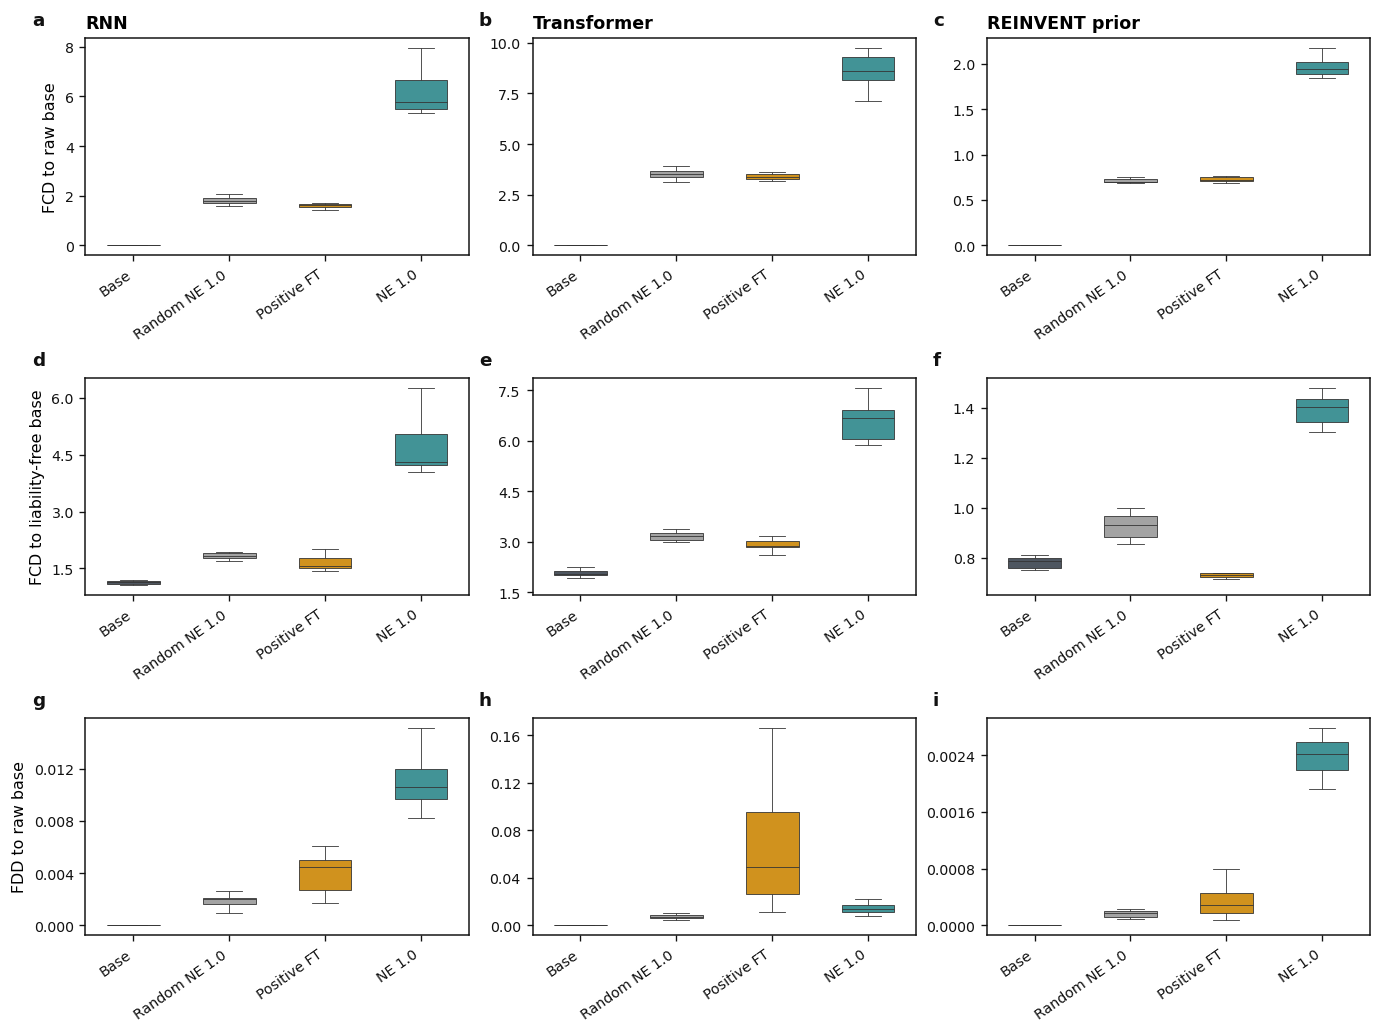

In [9]:
SHIFT_SOURCES = {
    "RNN": {
        "path": RESULTS / "objectives/guacamol_rnn_chelator_removal/analysis/distribution_distance_fcd_base_filtered_selected/distribution_distance_metrics.csv",
        "models": {
            "base": "Base", "random_neon_lambda_1.0": "Random NE 1.0",
            "positive": "Positive FT", "neon_lambda_1.0": "NE 1.0",
        },
        "liability_free": "base_filtered",
    },
    "Transformer": {
        "path": RESULTS / "objectives/guacamol_transformer_chelator_lastblock_final/analysis/distribution_distance_fcd_10seed/distribution_distance_metrics.csv",
        "models": {
            "base": "Base", "random_neon_last_block_output_lambda_1.0": "Random NE 1.0",
            "positive": "Positive FT", "neon_last_block_output_lambda_1.0": "NE 1.0",
        },
        "liability_free": "good",
    },
    "REINVENT prior": {
        "path": RESULTS / "external/reinvent4/chelator_replicates/analysis/distribution_distance_fcd/distribution_distance_metrics.csv",
        "models": {
            "base": "Base", "random_neon_lambda_1": "Random NE 1.0",
            "positive": "Positive FT", "neon_lambda_1": "NE 1.0",
        },
        "liability_free": "good",
    },
}
SHIFT_LABEL_ORDER = ["Base", "Random NE 1.0", "Positive FT", "NE 1.0"]
SHIFT_COLORS = {
    "Base": METHOD_COLORS["base"], "Random NE 1.0": METHOD_COLORS["random_ne"],
    "Positive FT": METHOD_COLORS["positive"], "NE 1.0": NE_LAMBDA_COLORS[1.00],
}

shift_frames = []
for generator, meta in SHIFT_SOURCES.items():
    frame = pd.read_csv(meta["path"])
    frame = frame[frame["seed"].isin(PAPER_SEEDS_10) & frame["model"].isin(meta["models"])].copy()
    frame["generator"] = generator
    frame["method_label"] = frame["model"].map(meta["models"])
    frame["reference_group"] = np.where(frame["reference"].eq("base"), "Raw base", np.where(frame["reference"].eq(meta["liability_free"]), "Liability-free base", None))
    shift_frames.append(frame[frame["reference_group"].notna()])
shift_data = pd.concat(shift_frames, ignore_index=True)
shift_data["method_label"] = pd.Categorical(shift_data["method_label"], SHIFT_LABEL_ORDER, ordered=True)

fig, axes = plt.subplots(3, 3, figsize=(11.4, 8.5), constrained_layout=True)
row_specs = [
    ("fcd", "Raw base", "FCD to raw base"),
    ("fcd", "Liability-free base", "FCD to liability-free base"),
    ("fdd", "Raw base", "FDD to raw base"),
]
for col, generator in enumerate(SHIFT_SOURCES):
    for row, (metric, reference, ylabel) in enumerate(row_specs):
        ax = axes[row, col]
        panel = shift_data[
            shift_data["generator"].eq(generator)
            & shift_data["reference_group"].eq(reference)
        ]
        sns.boxplot(
            data=panel, x="method_label", y=metric,
            order=SHIFT_LABEL_ORDER,
            palette=[SHIFT_COLORS[label] for label in SHIFT_LABEL_ORDER],
            width=0.55, linewidth=0.5, fliersize=0, ax=ax,
        )
        ax.set_title(generator if row == 0 else "", loc="left", fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel(ylabel if col == 0 else "")
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
        style_ax(ax)

label_subplots(fig, x=-0.14, y=1.04)
save_figure(fig, "si_metal_binding_distribution_shifts")
plt.show()
shift_data.to_csv(DATA_DIR / "si_metal_binding_distribution_shifts.csv", index=False)

## Statistical Summaries Supporting Main Figures

These sections collect the paired endpoint statistics generated during figure construction. They are intended for SI tables/plots, not for replacing the main-panel effect-size plots.

In [10]:
STATS_DIR = ROOT / "notebooks" / "figures" / "plotting_data"
STAT_FILES = {
    "GuacaMol QED endpoint tests": STATS_DIR / "guacamol_qed" / "guacamol_qed_endpoint_paired_t_stats.csv",
    "GuacaMol liability endpoint tests": STATS_DIR / "guacamol_liability" / "guacamol_liability_endpoint_paired_t_stats.csv",
    "REINVENT liability endpoint tests": STATS_DIR / "reinvent_liability" / "reinvent_liability_neon1_paired_t_stats.csv",
}

stats_tables = {}
for name, path in STAT_FILES.items():
    if path.exists():
        stats_tables[name] = pd.read_csv(path)
        print(f"Loaded {name}: {path.relative_to(ROOT)} ({len(stats_tables[name])} rows)")
    else:
        print(f"Missing {name}: {path.relative_to(ROOT)}")

Missing GuacaMol QED endpoint tests: notebooks/figures/plotting_data/guacamol_qed/guacamol_qed_endpoint_paired_t_stats.csv
Missing GuacaMol liability endpoint tests: notebooks/figures/plotting_data/guacamol_liability/guacamol_liability_endpoint_paired_t_stats.csv
Missing REINVENT liability endpoint tests: notebooks/figures/plotting_data/reinvent_liability/reinvent_liability_neon1_paired_t_stats.csv


### Liability-Erasure Endpoint Statistics Plan

For RNN, Transformer, and REINVENT liability-erasure experiments, we test two endpoint outcomes:

1. **Target liability hit fraction**: lower is better and tests whether the intended structural liability was removed.
2. **Valid, unique, liability-free yield**: higher is better and tests whether removal translates into more retained molecules per fixed sampling budget. REINVENT runs use the exact `usable_yield` column. Older RNN and Transformer runs did not store the novelty-aware intersection per molecule, so the SI statistic reconstructs a fixed-budget `valid_unique_liability_free_yield` from the sample files and labels it explicitly.

Comparisons are paired by seed and use NE as the focal method: NE vs Base, NE vs Random NE, and NE vs Positive FT. We report paired mean differences, 95% Student-t confidence intervals, exact two-sided paired sign-flip p-values, and Holm-adjusted p-values across the liability endpoint family.

In [11]:
LIABILITY_COMPARISONS = [
    ("vs Base", "base", "Base", METHOD_COLORS["base"]),
    ("vs Random NE", "random_ne", "Random NE", "#A3A3A3"),
    ("vs Positive FT", "positive", "Positive FT", METHOD_COLORS["positive"]),
]

# Inferential results are computed once by scripts/analyze_paper_statistics.py.
statistics_path = RESULTS / "paper_statistics/confirmatory_paired_comparisons.csv"
if not statistics_path.exists():
    raise FileNotFoundError(f"Run `make paper-statistics` first: {statistics_path}")
liability_stats = pd.read_csv(statistics_path)
liability_stats = liability_stats[
    liability_stats["experiment"].eq("liability")
    & liability_stats["comparator"].isin(["base", "random_ne", "positive"])
].copy()
liability_stats["comparison"] = liability_stats["comparator"].map({
    "base": "vs Base",
    "random_ne": "vs Random NE",
    "positive": "vs Positive FT",
})
lower_is_better = liability_stats["better"].eq("lower")
liability_stats["effect_favoring_ne"] = np.where(
    lower_is_better, -liability_stats["mean_difference"], liability_stats["mean_difference"]
)
liability_stats["effect_ci95_low"] = np.where(
    lower_is_better, -liability_stats["ci95_high"], liability_stats["ci95_low"]
)
liability_stats["effect_ci95_high"] = np.where(
    lower_is_better, -liability_stats["ci95_low"], liability_stats["ci95_high"]
)
print(f"Exact sign-flip comparison rows: {len(liability_stats):,}")
liability_stats.head()

Exact sign-flip comparison rows: 72


,experiment,generator,objective,objective_label,metric,metric_label,endpoint_role,better,focal_method,comparator,...,ci95_low,ci95_high,exact_sign_flip_p,all_differences_same_direction,family,holm_exact_p,comparison,effect_favoring_ne,effect_ci95_low,effect_ci95_high
0,liability,GuacaMol RNN,assay_interference,Assay interference,target_hit_fraction,Target liability hit fraction,primary,lower,ne,base,...,-0.054619,-0.044484,0.001953,True,liability__GuacaMol RNN__target_hit_fraction,0.023438,vs Base,0.049552,0.044484,0.054619
1,liability,GuacaMol RNN,assay_interference,Assay interference,target_hit_fraction,Target liability hit fraction,primary,lower,ne,random_ne,...,-0.080192,-0.058067,0.001953,True,liability__GuacaMol RNN__target_hit_fraction,0.023438,vs Random NE,0.069130,0.058067,0.080192
2,liability,GuacaMol RNN,assay_interference,Assay interference,target_hit_fraction,Target liability hit fraction,primary,lower,ne,positive,...,-0.012505,-0.006861,0.001953,True,liability__GuacaMol RNN__target_hit_fraction,0.023438,vs Positive FT,0.009683,0.006861,0.012505
3,liability,GuacaMol RNN,assay_interference,Assay interference,usable_yield,Usable yield,primary,higher,ne,base,...,-0.018363,-0.005757,0.005859,False,liability__GuacaMol RNN__usable_yield,0.023438,vs Base,-0.012060,-0.018363,-0.005757
4,liability,GuacaMol RNN,assay_interference,Assay interference,usable_yield,Usable yield,primary,higher,ne,random_ne,...,0.039966,0.072574,0.001953,True,liability__GuacaMol RNN__usable_yield,0.023438,vs Random NE,0.056270,0.039966,0.072574


/mnt/nas/PhD/Code/neon_molecular_generation/notebooks/figures/si/si_confirmatory_liability_effects.png


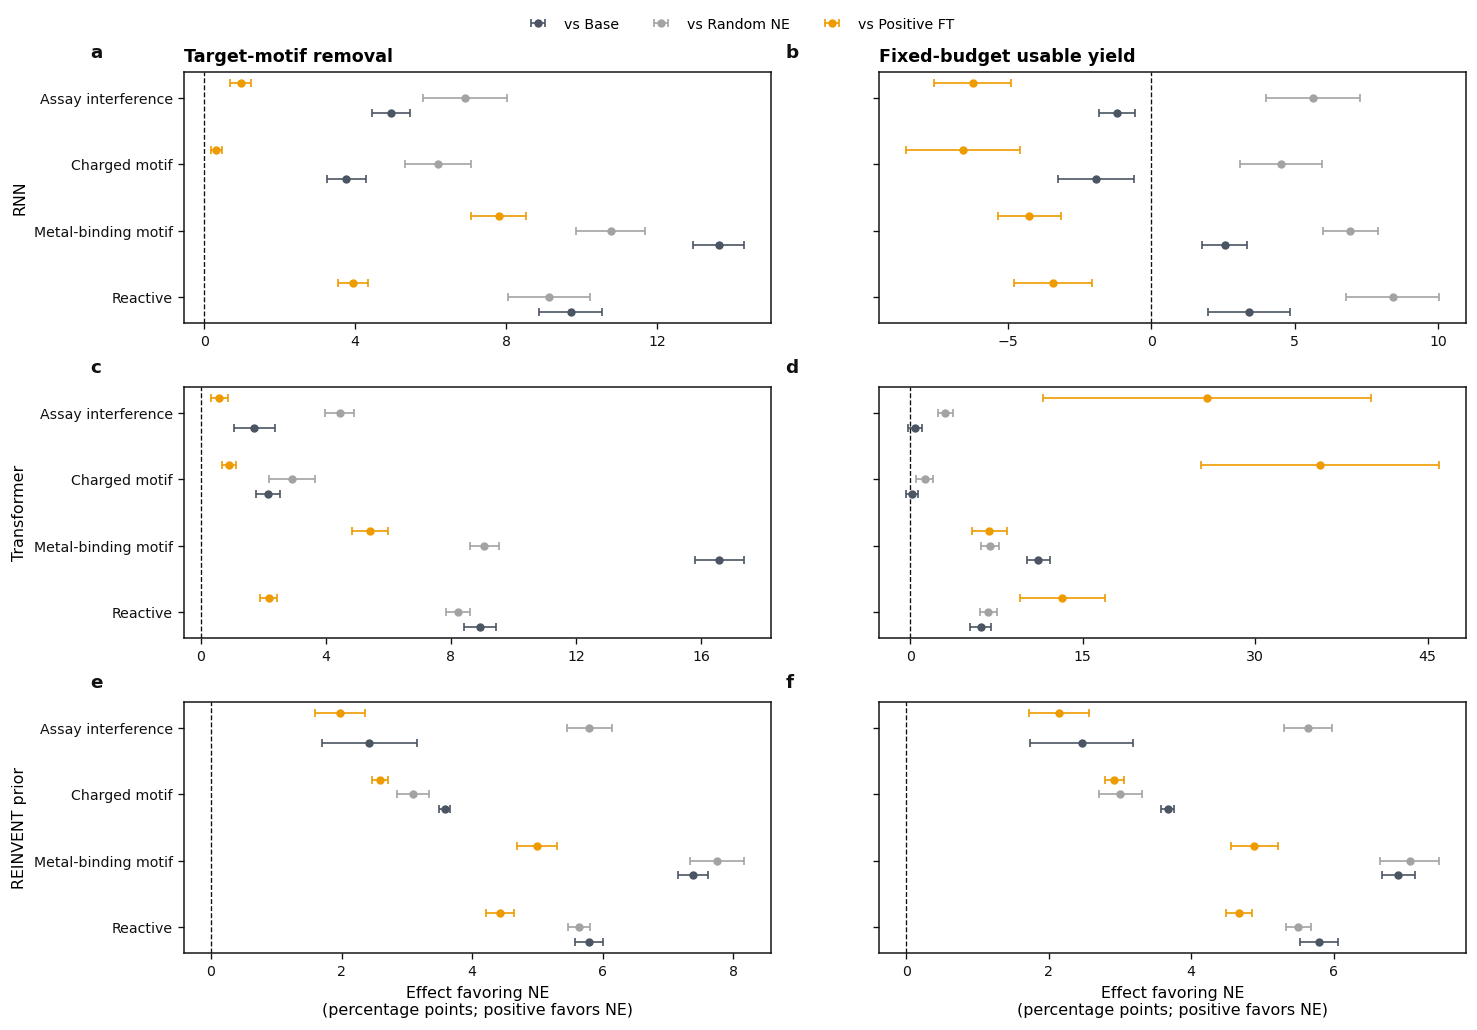

In [12]:
GENERATOR_ORDER = ["GuacaMol RNN", "GuacaMol Transformer", "REINVENT prior"]
GENERATOR_LABELS = {"GuacaMol RNN": "RNN", "GuacaMol Transformer": "Transformer", "REINVENT prior": "REINVENT prior"}
METRIC_ORDER = ["target_hit_fraction", "usable_yield"]
COMPARISON_ORDER = [name for name, *_ in LIABILITY_COMPARISONS]
COMPARISON_COLORS = {name: color for name, _, _, color in LIABILITY_COMPARISONS}
OBJECTIVE_ORDER = ["Reactive", "Metal-binding motif", "Charged motif", "Assay interference"]

fig, axes = plt.subplots(len(GENERATOR_ORDER), len(METRIC_ORDER), figsize=(12.2, 8.2), constrained_layout=True, sharex=False)
for row_idx, generator in enumerate(GENERATOR_ORDER):
    for col_idx, metric in enumerate(METRIC_ORDER):
        ax = axes[row_idx, col_idx]
        panel = liability_stats[(liability_stats["generator"].eq(generator)) & (liability_stats["metric"].eq(metric))].copy()
        panel["objective_label"] = pd.Categorical(panel["objective_label"], OBJECTIVE_ORDER, ordered=True)
        panel["comparison"] = pd.Categorical(panel["comparison"], COMPARISON_ORDER, ordered=True)
        panel = panel.sort_values(["objective_label", "comparison"])
        y_base = {objective: i for i, objective in enumerate(OBJECTIVE_ORDER)}
        offsets = {"vs Base": -0.22, "vs Random NE": 0.0, "vs Positive FT": 0.22}
        for comparison in COMPARISON_ORDER:
            part = panel[panel["comparison"].astype(str).eq(comparison)]
            if part.empty:
                continue
            y = [y_base[obj] + offsets[comparison] for obj in part["objective_label"].astype(str)]
            x = 100.0 * part["effect_favoring_ne"].to_numpy(dtype=float)
            xerr = np.vstack([x - 100.0 * part["effect_ci95_low"].to_numpy(dtype=float), 100.0 * part["effect_ci95_high"].to_numpy(dtype=float) - x])
            ax.errorbar(
                x,
                y,
                xerr=xerr,
                fmt="o",
                color=COMPARISON_COLORS[comparison],
                ecolor=COMPARISON_COLORS[comparison],
                elinewidth=1.0,
                capsize=2.5,
                markersize=4.0,
                label=comparison if row_idx == 0 and col_idx == 0 else None,
            )
        ax.axvline(0, color="#111111", lw=0.8, ls="--")
        ax.set_yticks(range(len(OBJECTIVE_ORDER)))
        ax.set_yticklabels(OBJECTIVE_ORDER if col_idx == 0 else [])
        if row_idx == 0:
            title = "Target-motif removal" if metric == "target_hit_fraction" else "Fixed-budget usable yield"
            ax.set_title(title, loc="left", fontweight="bold")
        if col_idx == 0:
            ax.set_ylabel(GENERATOR_LABELS[generator])
            ax.set_xlabel("Effect favoring NE\n(percentage points; positive favors NE)" if row_idx == len(GENERATOR_ORDER) - 1 else "")
        else:
            ax.set_ylabel("")
            ax.set_xlabel("Effect favoring NE\n(percentage points; positive favors NE)" if row_idx == len(GENERATOR_ORDER) - 1 else "")
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
        style_ax(ax)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.035))
label_subplots(fig, x=-0.16, y=1.04)
save_figure(fig, "si_confirmatory_liability_effects")
plt.show()

## SI Figure: SemlaFlow Endpoint Comparison

Endpoint distributions for SemlaFlow controls, standard NE, and CNE. CNE uses a liability-free task vector as a validity-correction direction. The norm-matched random-correction control tests whether a correction without liability-specific selection provides the same effect.

/tmp/ipykernel_15504/3358439048.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_15504/3358439048.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([SEMLA_LABELS[m] for m in SEMLA_ORDER], rotation=35, ha="right")
/tmp/ipykernel_15504/3358439048.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_15504/3358439048.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([SEMLA_LABELS[m] for m in SEMLA_ORDER], rotation=35, ha="right")
/tmp/ipykernel_15504

/mnt/nas/PhD/Code/neon_molecular_generation/notebooks/figures/si/si_semlaflow_endpoint_comparison.png


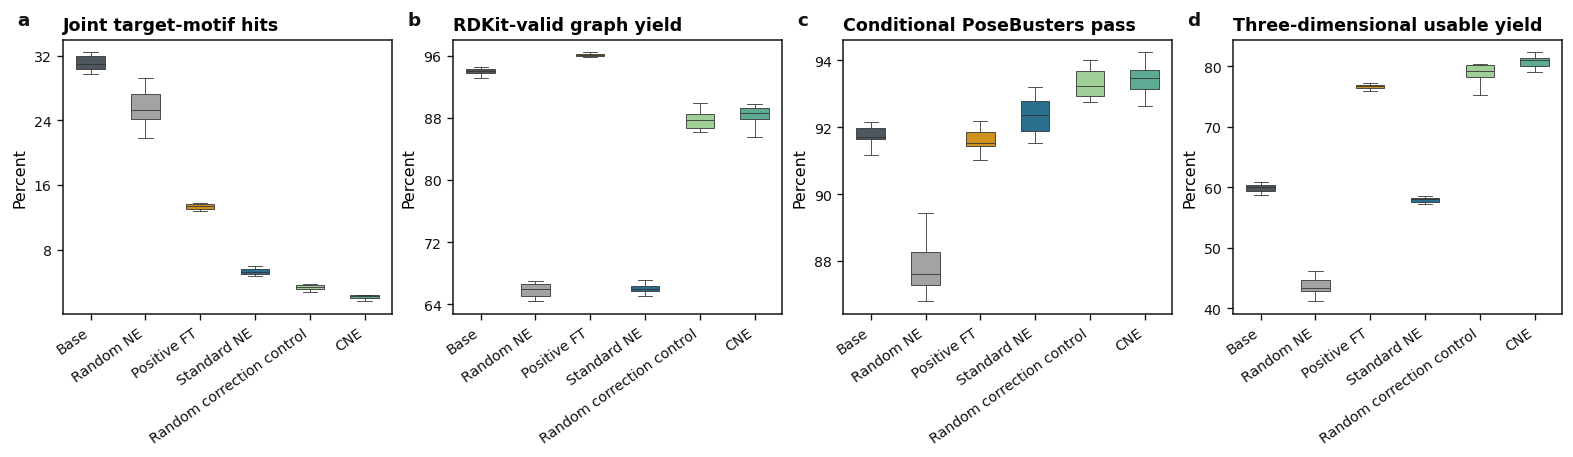

In [13]:
semla_root = RESULTS / "external" / "semlaflow" / "four_liability_joint_replicates" / "analysis"
semla_endpoints = pd.read_csv(semla_root / "replicate_metrics.csv")
semla_pose = pd.read_csv(semla_root / "posebusters_replicate_metrics.csv")
semla_endpoints = semla_endpoints[semla_endpoints["seed"].isin(PAPER_SEEDS_10)].copy()
semla_pose = semla_pose[semla_pose["seed"].isin(PAPER_SEEDS_10)].copy()
SEMLA_POSE_MAP = {
    "standard_ne_2p5": "full_model_neon_lambda_2p5",
    "random_ne_2p5": "full_model_random_neon_lambda_2p5",
    "norm_matched_random_corrected_ne_2p5": "full_model_norm_matched_random_corrected_neon_lambda_2p5",
    "positive_corrected_ne_2p5": "full_model_positive_corrected_neon_lambda_2p5",
}
semla_pose["model"] = semla_pose["model"].map(SEMLA_POSE_MAP).fillna(semla_pose["model"])
SEMLA_ORDER = [
    "base", "full_model_random_neon_lambda_2p5", "positive_tuned",
    "full_model_neon_lambda_2p5", "full_model_norm_matched_random_corrected_neon_lambda_2p5",
    "full_model_positive_corrected_neon_lambda_2p5",
]
SEMLA_LABELS = {
    "base": "Base", "full_model_random_neon_lambda_2p5": "Random NE",
    "positive_tuned": "Positive FT", "full_model_neon_lambda_2p5": "Standard NE",
    "full_model_norm_matched_random_corrected_neon_lambda_2p5": "Random correction control",
    "full_model_positive_corrected_neon_lambda_2p5": "CNE",
}
SEMLA_COLORS = {
    "base": METHOD_COLORS["base"], "full_model_random_neon_lambda_2p5": METHOD_COLORS["random_ne"],
    "positive_tuned": METHOD_COLORS["positive"], "full_model_neon_lambda_2p5": NE_LAMBDA_COLORS[0.50],
    "full_model_norm_matched_random_corrected_neon_lambda_2p5": "#99D98C",
    "full_model_positive_corrected_neon_lambda_2p5": "#52B69A",
}

fig, axes = plt.subplots(1, 4, figsize=(13.0, 3.7), constrained_layout=True)
specs = [
    (semla_endpoints, "four_liability_hit_fraction", "Joint target-motif hits"),
    (semla_endpoints, "valid_fraction", "RDKit-valid graph yield"),
    (semla_pose, "posebusters_all_checks_fraction_of_rdkit_valid", "Conditional PoseBusters pass"),
    (semla_pose, "usable_3d_yield", "Three-dimensional usable yield"),
]
for ax, (frame, metric, title) in zip(axes, specs):
    panel = frame[frame["model"].isin(SEMLA_ORDER)].copy()
    panel[metric] = 100.0 * panel[metric]
    sns.boxplot(
        data=panel, x="model", y=metric, order=SEMLA_ORDER,
        palette=[SEMLA_COLORS[m] for m in SEMLA_ORDER],
        width=0.52, linewidth=0.5, fliersize=0, ax=ax,
    )
    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Percent")
    ax.set_xticklabels([SEMLA_LABELS[m] for m in SEMLA_ORDER], rotation=35, ha="right")
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    style_ax(ax)

label_subplots(fig, x=-0.14, y=1.04)
save_figure(fig, "si_semlaflow_endpoint_comparison")
plt.show()

## SI Figure: Confirmatory SemlaFlow Effect Estimates

This figure shows paired effects of CNE relative to each confirmatory SemlaFlow comparator. Effects are oriented so that positive values always favor CNE. Exact sign-flip tests and Holm-adjusted values are reported in Supplementary Table S5.

/mnt/nas/PhD/Code/neon_molecular_generation/notebooks/figures/si/si_semlaflow_confirmatory_effects.png


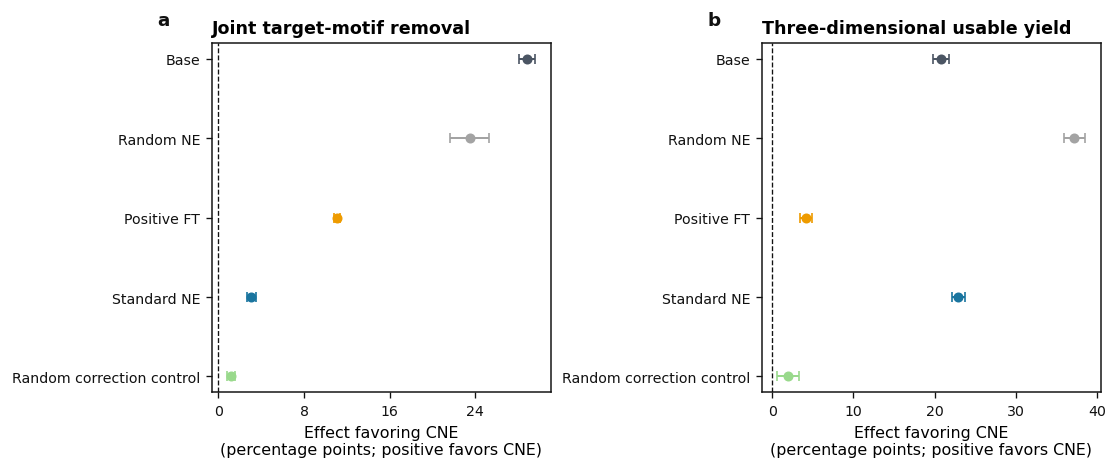

In [14]:
semla_stats = pd.read_csv(statistics_path)
semla_stats = semla_stats[semla_stats["experiment"].eq("semlaflow")].copy()
semla_lower_is_better = semla_stats["better"].eq("lower")
semla_stats["effect_favoring_cne"] = np.where(
    semla_lower_is_better, -semla_stats["mean_difference"], semla_stats["mean_difference"]
)
semla_stats["effect_ci95_low"] = np.where(
    semla_lower_is_better, -semla_stats["ci95_high"], semla_stats["ci95_low"]
)
semla_stats["effect_ci95_high"] = np.where(
    semla_lower_is_better, -semla_stats["ci95_low"], semla_stats["ci95_high"]
)

SEMLA_COMPARATOR_ORDER = ["base", "random_ne", "positive", "standard_ne", "random_corrected_control"]
SEMLA_COMPARATOR_LABELS = {
    "base": "Base",
    "random_ne": "Random NE",
    "positive": "Positive FT",
    "standard_ne": "Standard NE",
    "random_corrected_control": "Random correction control",
}
SEMLA_COMPARATOR_COLORS = {
    "base": METHOD_COLORS["base"],
    "random_ne": METHOD_COLORS["random_ne"],
    "positive": METHOD_COLORS["positive"],
    "standard_ne": NE_LAMBDA_COLORS[0.50],
    "random_corrected_control": "#99D98C",
}

fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.8), constrained_layout=True)
for ax, metric, title in zip(
    axes,
    ["target_hit_fraction", "usable_3d_yield"],
    ["Joint target-motif removal", "Three-dimensional usable yield"],
):
    panel = semla_stats[semla_stats["metric"].eq(metric)].set_index("comparator").reindex(SEMLA_COMPARATOR_ORDER).dropna(subset=["mean_difference"])
    y = np.arange(len(panel), dtype=float)
    x = 100.0 * panel["effect_favoring_cne"].to_numpy(dtype=float)
    low = 100.0 * panel["effect_ci95_low"].to_numpy(dtype=float)
    high = 100.0 * panel["effect_ci95_high"].to_numpy(dtype=float)
    for idx, comparator in enumerate(panel.index):
        ax.errorbar(
            x[idx], y[idx], xerr=[[x[idx] - low[idx]], [high[idx] - x[idx]]],
            fmt="o", color=SEMLA_COMPARATOR_COLORS[comparator],
            ecolor=SEMLA_COMPARATOR_COLORS[comparator], elinewidth=1.2, capsize=3.0, markersize=5.0,
        )
    ax.axvline(0, color="#111111", lw=0.8, ls="--")
    ax.set_yticks(y)
    ax.set_yticklabels([SEMLA_COMPARATOR_LABELS[key] for key in panel.index])
    ax.invert_yaxis()
    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_xlabel("Effect favoring CNE\n(percentage points; positive favors CNE)")
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    style_ax(ax)

label_subplots(fig, x=-0.16, y=1.04)
save_figure(fig, "si_semlaflow_confirmatory_effects")
plt.show()

### Exact liability statistics tables

The p-value heatmap has been removed because color-coded transformed p-values obscure effect direction and magnitude. The forest plot loads the authoritative results from `results/paper_statistics/confirmatory_paired_comparisons.csv`, generated with `make paper-statistics`. It shows paired mean differences and 95% Student-$t$ confidence intervals; exact sign-flip and Holm-adjusted p-values are reported in the generated Supplementary Tables.

In [15]:
# Export all loaded statistics tables into the SI plotting-data folder for traceability.
for name, table in stats_tables.items():
    safe = name.lower().replace(":", "").replace(" ", "_").replace("-", "_")
    table.to_csv(DATA_DIR / f"{safe}.csv", index=False)

## SI Figure: SemlaFlow Exploratory Parameter Selection

All panels are exploratory screens on development seed 11 documenting configuration selection, not inferential evidence. Hyperparameter development used the oxygen–nitrogen single-bond proxy objective; transfer to the four medicinal-chemistry liability families was checked before the replicated joint-objective experiment. Panels c and d show the original unnormalized random-correction diagnostic, in which the negative-extrapolation delta is combined with a fine-tuning delta learned from randomly sampled molecules. In the confirmatory experiment, CNE uses a liability-free validity-correction direction, and the random-corrected direction is retained as a norm-matched mechanistic control.

/mnt/nas/PhD/Code/neon_molecular_generation/notebooks/figures/si/si_semlaflow_parameter_selection.png


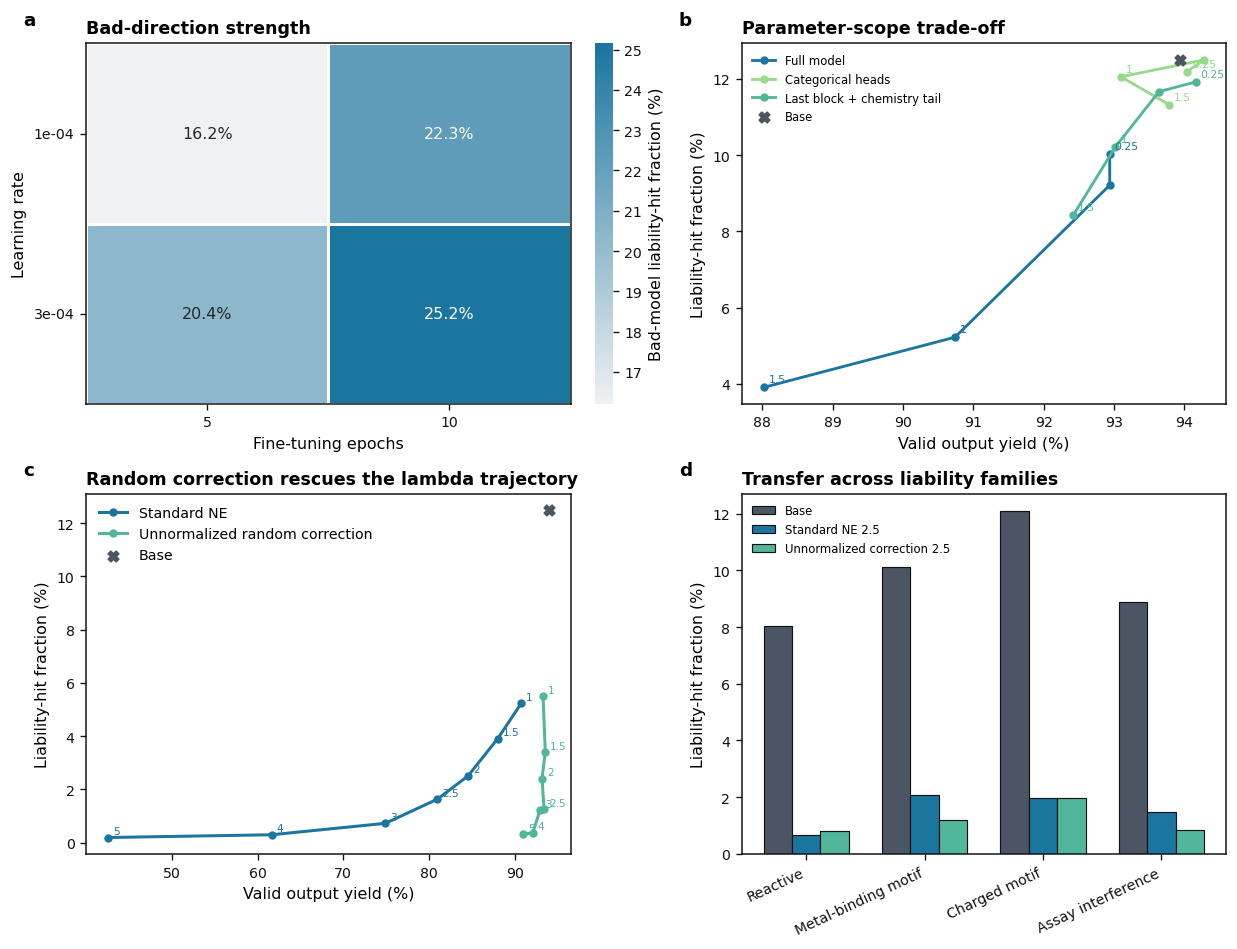

In [16]:
SEMLA_PILOT_ROOT = RESULTS / "development" / "semlaflow_parameter_selection"
SEMLA_PILOT_PATHS = {
    "diagnostic": SEMLA_PILOT_ROOT / "bad_direction_diagnostic.csv",
    "scope": SEMLA_PILOT_ROOT / "scope_screen.csv",
    "lambda": SEMLA_PILOT_ROOT / "lambda_screen.csv",
    "transfer": SEMLA_PILOT_ROOT / "liability_transfer.csv",
}
missing = [str(path) for path in SEMLA_PILOT_PATHS.values() if not path.exists()]
if missing:
    raise FileNotFoundError("Missing SemlaFlow pilot summaries:\n" + "\n".join(missing))

semla_diagnostic = pd.read_csv(SEMLA_PILOT_PATHS["diagnostic"])
semla_scope = pd.read_csv(SEMLA_PILOT_PATHS["scope"])
semla_lambda = pd.read_csv(SEMLA_PILOT_PATHS["lambda"])
semla_transfer = pd.read_csv(SEMLA_PILOT_PATHS["transfer"])

SEMLA_SCOPE_LABELS = {
    "full_model": "Full model",
    "categorical_heads": "Categorical heads",
    "last_block_chemistry_tail": "Last block + chemistry tail",
}
SEMLA_SCOPE_COLORS = {
    "full_model": "#1A759F",
    "categorical_heads": "#99D98C",
    "last_block_chemistry_tail": "#52B69A",
}
SEMLA_TRANSFER_ORDER = [
    "reactive_hit",
    "chelator_hit",
    "charged_motif_hit",
    "assay_interference_hit",
]
SEMLA_TRANSFER_LABELS = {
    "reactive_hit": "Reactive",
    "chelator_hit": "Metal-binding motif",
    "charged_motif_hit": "Charged motif",
    "assay_interference_hit": "Assay interference",
}
SEMLA_PILOT_METHODS = {
    "base": ("Base", METHOD_COLORS["base"]),
    "full_model_neon_lambda_2p5": ("Standard NE 2.5", NE_LAMBDA_COLORS[0.50]),
    "full_model_random_corrected_neon_lambda_2p5": ("Unnormalized correction 2.5", "#52B69A"),
}

def parse_semla_lambda(model: str) -> float:
    return float(model.rsplit("_lambda_", 1)[1].replace("p", "."))

fig, axes = plt.subplots(2, 2, figsize=(10.2, 7.8), constrained_layout=True)

# a: bad-direction strength.
ax = axes[0, 0]
heat = (
    semla_diagnostic
    .pivot(index="learning_rate", columns="bad_epochs", values="bad_hit_fraction")
    .sort_index()
    .sort_index(axis=1)
)
heat_percent = 100.0 * heat
sns.heatmap(
    heat_percent,
    annot=heat_percent.map(lambda value: f"{value:.1f}%"),
    fmt="",
    cmap=sns.light_palette("#1A759F", as_cmap=True),
    cbar_kws={"label": "Bad-model liability-hit fraction (%)"},
    linewidths=0.8,
    linecolor="white",
    ax=ax,
)
ax.set_xlabel("Fine-tuning epochs")
ax.set_ylabel("Learning rate")
ax.set_yticklabels([f"{value:.0e}" for value in heat.index], rotation=0)
ax.set_title("Bad-direction strength", loc="left", fontweight="bold")
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("#111111")
    spine.set_linewidth(0.9)

# b: standard-NE scope screen.
ax = axes[0, 1]
scope_rows = []
for _, row in semla_scope.iterrows():
    model = str(row["model"])
    if "random_corrected" in model or "_neon_lambda_" not in model:
        continue
    for scope in SEMLA_SCOPE_LABELS:
        if model.startswith(f"{scope}_neon_lambda_"):
            scope_rows.append({
                "scope": scope,
                "lambda": parse_semla_lambda(model),
                "valid_fraction": row["valid_fraction"],
                "objective_hit_fraction": row["objective_hit_fraction"],
            })
scope_plot = pd.DataFrame(scope_rows)
for scope in SEMLA_SCOPE_LABELS:
    part = scope_plot[scope_plot["scope"].eq(scope)].sort_values("lambda")
    ax.plot(
        100 * part["valid_fraction"],
        100 * part["objective_hit_fraction"],
        marker="o",
        linewidth=1.7,
        markersize=4,
        color=SEMLA_SCOPE_COLORS[scope],
        label=SEMLA_SCOPE_LABELS[scope],
    )
    for _, row in part.iterrows():
        if row["lambda"] in (0.25, 1.0, 1.5):
            ax.annotate(
                f'{row["lambda"]:g}',
                (100 * row["valid_fraction"], 100 * row["objective_hit_fraction"]),
                xytext=(3, 3),
                textcoords="offset points",
                fontsize=6.5,
                color=SEMLA_SCOPE_COLORS[scope],
            )
base_scope = semla_scope[semla_scope["model"].eq("base")].iloc[0]
ax.scatter(
    100 * base_scope["valid_fraction"],
    100 * base_scope["objective_hit_fraction"],
    marker="X",
    s=40,
    color=METHOD_COLORS["base"],
    label="Base",
    zorder=5,
)
ax.set_xlabel("Valid output yield (%)")
ax.set_ylabel("Liability-hit fraction (%)")
ax.set_title("Parameter-scope trade-off", loc="left", fontweight="bold")
ax.legend(frameon=False, fontsize=7)
style_ax(ax)

# c: full-model lambda trajectory.
ax = axes[1, 0]
lambda_rows = []
for _, row in semla_lambda.iterrows():
    model = str(row["model"])
    if model.startswith("full_model_neon_lambda_"):
        family = "Standard NE"
    elif model.startswith("full_model_random_corrected_neon_lambda_"):
        family = "Unnormalized random correction"
    else:
        continue
    lambda_rows.append({
        "family": family,
        "lambda": parse_semla_lambda(model),
        "valid_fraction": row["valid_fraction"],
        "objective_hit_fraction": row["objective_hit_fraction"],
    })
lambda_plot = pd.DataFrame(lambda_rows)
family_colors = {"Standard NE": NE_LAMBDA_COLORS[0.50], "Unnormalized random correction": "#52B69A"}
for family in ("Standard NE", "Unnormalized random correction"):
    part = lambda_plot[lambda_plot["family"].eq(family)].sort_values("lambda")
    ax.plot(
        100 * part["valid_fraction"],
        100 * part["objective_hit_fraction"],
        marker="o",
        linewidth=1.8,
        markersize=4,
        color=family_colors[family],
        label=family,
    )
    for _, row in part.iterrows():
        ax.annotate(
            f'{row["lambda"]:g}',
            (100 * row["valid_fraction"], 100 * row["objective_hit_fraction"]),
            xytext=(3, 2),
            textcoords="offset points",
            fontsize=6.2,
            color=family_colors[family],
        )
base_lambda = semla_lambda[semla_lambda["model"].eq("base")].iloc[0]
ax.scatter(
    100 * base_lambda["valid_fraction"],
    100 * base_lambda["objective_hit_fraction"],
    marker="X",
    s=40,
    color=METHOD_COLORS["base"],
    label="Base",
    zorder=5,
)
ax.set_xlabel("Valid output yield (%)")
ax.set_ylabel("Liability-hit fraction (%)")
ax.set_title("Random correction rescues the lambda trajectory", loc="left", fontweight="bold")
ax.legend(frameon=False)
style_ax(ax)

# d: transfer to the four paper liability families.
ax = axes[1, 1]
x = np.arange(len(SEMLA_TRANSFER_ORDER), dtype=float)
width = 0.24
for offset_index, (model, (label, color)) in enumerate(SEMLA_PILOT_METHODS.items()):
    part = (
        semla_transfer[semla_transfer["model"].eq(model)]
        .set_index("objective")
        .reindex(SEMLA_TRANSFER_ORDER)
    )
    ax.bar(
        x + (offset_index - 1) * width,
        100 * part["objective_hit_fraction"],
        width=width,
        color=color,
        edgecolor="#111111",
        linewidth=0.7,
        label=label,
    )
ax.set_xticks(
    x,
    [SEMLA_TRANSFER_LABELS[objective] for objective in SEMLA_TRANSFER_ORDER],
    rotation=25,
    ha="right",
)
ax.set_ylabel("Liability-hit fraction (%)")
ax.set_title("Transfer across liability families", loc="left", fontweight="bold")
ax.legend(frameon=False, fontsize=7)
style_ax(ax)

for panel_label, panel_ax in zip("abcd", axes.flat):
    panel_ax.text(-0.13, 1.04, panel_label, transform=panel_ax.transAxes, fontsize=11, fontweight="bold", va="bottom")
save_figure(fig, "si_semlaflow_parameter_selection")
plt.show()

semla_diagnostic.to_csv(DATA_DIR / "si_semlaflow_bad_direction_screen.csv", index=False)
scope_plot.to_csv(DATA_DIR / "si_semlaflow_scope_screen.csv", index=False)
lambda_plot.to_csv(DATA_DIR / "si_semlaflow_lambda_screen.csv", index=False)
semla_transfer.to_csv(DATA_DIR / "si_semlaflow_liability_transfer.csv", index=False)

## SI Figure: Fine-tuning Epoch Sensitivity

Development-seed analysis of reactive-liability removal for the RNN, Transformer, and REINVENT prior. The figure jointly audits liability removal, validity, and fixed-budget unique usable scaffold yield. It is a sensitivity analysis rather than a confirmatory multi-seed comparison. Generate the input tables with `scripts/analyze_epoch_sensitivity_scaffolds.py`.

/mnt/nas/PhD/Code/neon_molecular_generation/notebooks/figures/si/si_generator_epoch_sensitivity.png


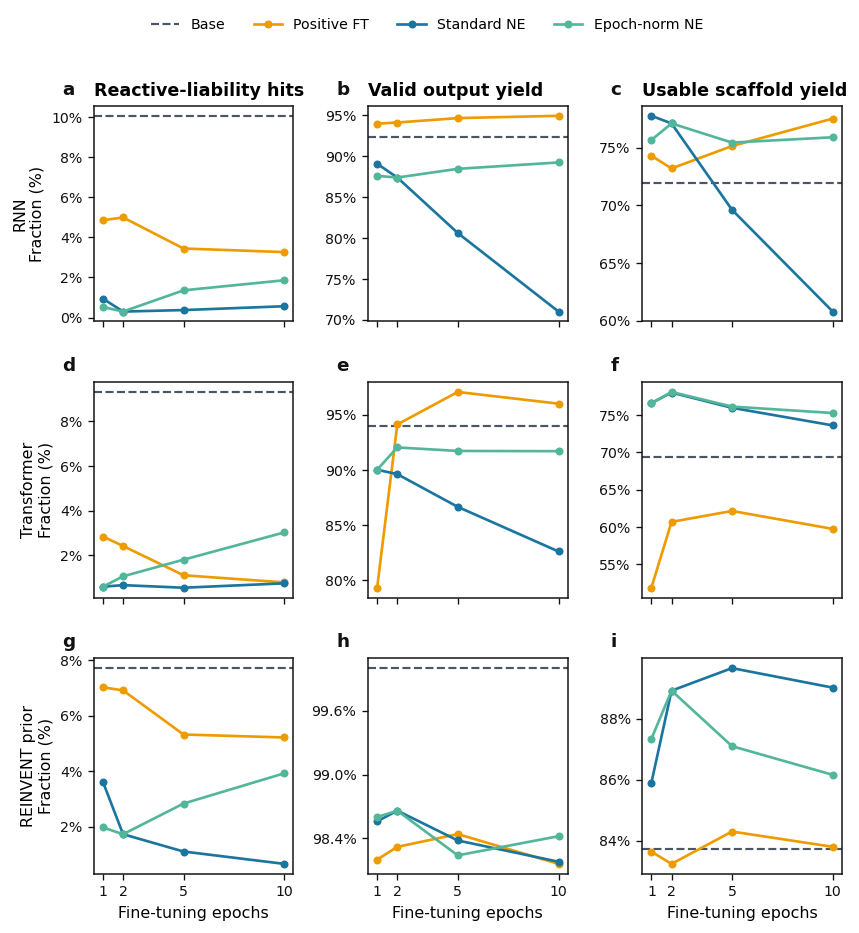

In [17]:
EPOCH_SENSITIVITY_ROOTS = {
    "RNN": RESULTS / "development/guacamol_rnn_reactive_epoch_sensitivity_seed_11",
    "Transformer": RESULTS / "development/guacamol_transformer_reactive_epoch_sensitivity_seed_11",
    "REINVENT4": RESULTS / "development/reinvent_reactive_epoch_sensitivity_seed_11",
}
EPOCH_ARCHITECTURE_LABELS = {"RNN": "RNN", "Transformer": "Transformer", "REINVENT4": "REINVENT prior"}

epoch_frames = []
for architecture, result_dir in EPOCH_SENSITIVITY_ROOTS.items():
    endpoints = pd.read_csv(result_dir / "epoch_sensitivity_summary.csv")
    scaffolds = pd.read_csv(result_dir / "usable_scaffold_metrics.csv")
    merged = endpoints.merge(
        scaffolds[[
            "model",
            "n_unique_usable_scaffolds",
            "unique_usable_scaffold_yield",
            "unique_scaffold_fraction_among_usable",
            "top10_usable_scaffold_fraction",
        ]],
        on="model",
        how="inner",
        validate="one_to_one",
    )
    merged["architecture"] = architecture
    merged["direction_kind"] = merged["direction_kind"].replace({
        "raw_ne": "standard_ne",
        "norm_matched_ne": "epoch_norm_ne",
    })
    merged["valid_output_yield"] = merged["n_valid"] / merged["n_sampled"]
    epoch_frames.append(merged)
epoch_sensitivity = pd.concat(epoch_frames, ignore_index=True)

EPOCH_METHODS = {
    "positive_finetune": ("Positive FT", METHOD_COLORS["positive"]),
    "standard_ne": ("Standard NE", NE_LAMBDA_COLORS[0.50]),
    "epoch_norm_ne": ("Epoch-norm NE", "#52B69A"),
}
EPOCH_PANELS = [
    ("reactive_hit_fraction", "Reactive-liability hits"),
    ("valid_output_yield", "Valid output yield"),
    ("unique_usable_scaffold_yield", "Usable scaffold yield"),
]

fig, axes = plt.subplots(3, 3, figsize=(7.2, 7.7), sharex=True)
for row_index, architecture in enumerate(EPOCH_SENSITIVITY_ROOTS):
    architecture_data = epoch_sensitivity[epoch_sensitivity["architecture"].eq(architecture)]
    base_row = architecture_data[architecture_data["direction_kind"].eq("base")].iloc[0]
    for column_index, (metric, title) in enumerate(EPOCH_PANELS):
        ax = axes[row_index, column_index]
        ax.axhline(
            100 * base_row[metric],
            color=METHOD_COLORS["base"],
            linestyle="--",
            linewidth=1.3,
            label="Base",
            zorder=1,
        )
        for direction_kind, (label, color) in EPOCH_METHODS.items():
            part = (
                architecture_data[architecture_data["direction_kind"].eq(direction_kind)]
                .sort_values("epoch")
            )
            ax.plot(
                part["epoch"],
                100 * part[metric],
                marker="o",
                markersize=3.8,
                linewidth=1.6,
                color=color,
                label=label,
                zorder=2,
            )
        ax.set_xticks([1, 2, 5, 10])
        if architecture == "REINVENT4" and metric == "valid_output_yield":
            ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
            ax.yaxis.set_major_formatter(PercentFormatter(100, decimals=1))
        else:
            ax.yaxis.set_major_formatter(PercentFormatter(100, decimals=0))
        if row_index == 0:
            ax.set_title(title, loc="left", fontweight="bold")
        if column_index == 0:
            ax.set_ylabel(f"{EPOCH_ARCHITECTURE_LABELS[architecture]}\nFraction (%)")
        if row_index == len(EPOCH_SENSITIVITY_ROOTS) - 1:
            ax.set_xlabel("Fine-tuning epochs")
        style_ax(ax)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.01), ncol=4, frameon=False)
fig.tight_layout(rect=(0, 0, 1, 0.945), h_pad=3.25, w_pad=1.15)
label_subplots(fig, labels=list("abcdefghi"), x=-0.16, y=1.035)
save_figure(fig, "si_generator_epoch_sensitivity")
plt.show()

epoch_sensitivity.to_csv(DATA_DIR / "si_generator_epoch_sensitivity.csv", index=False)